# Lab: Word Embeddings

**Objective:** Understand how words become vectors and measure similarity in embedding spaces.

The lab is split into following topics:

1. **Words as Vectors:** GloVe, Word2Vec, FastText
2. **Geometry of Meaning:** Similarity metrics, analogy arithmetic, visualization4.
3. **(EXTRA) Text and Images:** CLIP multimodal retrieval

## Setup & Imports

In [1]:
# Install dependencies
!pip install -q gensim==4.4.0 feedparser plotly open_clip_torch

import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00


In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from collections import Counter
import time
import sys

# NLP / ML imports
import gensim
import gensim.downloader as api
from gensim.models import Word2Vec, FastText
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
from scipy.spatial.distance import cosine as scipy_cosine

# RSS feeds
import feedparser
import json
from urllib.request import urlopen

# Reproducibility
SEED = 42
np.random.seed(SEED)

print(f"gensim version: {gensim.__version__}")
print(f"numpy version: {np.__version__}")
print("Setup complete!")

gensim version: 4.4.0
numpy version: 2.0.2
Setup complete!


### Helper Functions

In [3]:
# ---- Plotting helpers ----

CATEGORY_COLORS = {
    'animals': '#e41a1c',
    'countries': '#377eb8',
    'colors': '#4daf4a',
    'emotions': '#984ea3',
    'technology': '#ff7f00',
    'sports': '#a65628',
    'food': '#f781bf',
    'music': '#999999',
    'science': '#66c2a5',
    'professions': '#fc8d62',
}

def plot_vectors_2d(words, vectors_2d, title, categories=None, cat_colors=None):
    """Interactive 2D scatter plot of word vectors using plotly."""
    df = pd.DataFrame({
        'x': vectors_2d[:, 0],
        'y': vectors_2d[:, 1],
        'word': words,
        'category': categories if categories is not None else ['default'] * len(words)
    })
    color_map = cat_colors if cat_colors else None
    fig = px.scatter(df, x='x', y='y', text='word', color='category',
                     color_discrete_map=color_map, title=title)
    fig.update_traces(textposition='top center', marker=dict(size=10))
    fig.update_layout(width=700, height=500, showlegend=True)
    fig.show()

def plot_vectors_2d_matplotlib(words, vectors_2d, title, categories=None, cat_colors=None):
    """Static 2D scatter plot using matplotlib (fallback)."""
    fig, ax = plt.subplots(figsize=(10, 7))
    if categories is not None and cat_colors is not None:
        unique_cats = list(dict.fromkeys(categories))
        for cat in unique_cats:
            mask = [c == cat for c in categories]
            pts = vectors_2d[mask]
            color = cat_colors.get(cat, '#333333')
            ax.scatter(pts[:, 0], pts[:, 1], c=color, label=cat, s=80, alpha=0.8)
    else:
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=80, alpha=0.8)
    for i, word in enumerate(words):
        ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                    fontsize=9, ha='center', va='bottom')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()



print("Helper functions defined.")

Helper functions defined.


---
## GloVe: Pre-trained Word Vectors


**GloVe (Global Vectors for Word Representation)** learns word embeddings by factorizing the word-word co-occurrence matrix from a large corpus.

**Key idea:** If words $i$ and $j$ frequently co-occur, their vectors should be close. The GloVe objective minimizes:

$$J = \sum_{i,j=1}^{V} f(X_{ij}) \left( \mathbf{w}_i^T \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$

where:
- $X_{ij}$ = number of times word $j$ appears in context of word $i$
- $f(X_{ij})$ = weighting function (caps influence of very frequent pairs)
- $\mathbf{w}_i, \tilde{\mathbf{w}}_j$ = word and context vectors

**Result:** Each word gets a dense vector (we'll use 50 dimensions) that captures semantic relationships.

"Try to make the mathematical similarity (dot product) of two word vectors match how often they appear together (log count). But, make sure to adjust for words that are naturally super common (biases), and don't let ridiculously frequent word pairs completely hijack the learning process (weighting function)."


For more information, check: https://nlp.stanford.edu/projects/glove/

In [4]:
# Load pre-trained GloVe vectors (50d, trained on Wikipedia + Gigaword, ~65 MB)
print("Downloading GloVe vectors (this may take a minute)...")
glove = api.load('glove-wiki-gigaword-50')
# For higher quality (but slower): glove = api.load('glove-wiki-gigaword-300')
print(f"Vocabulary size: {len(glove):,}")
print(f"Vector dimension: {glove.vector_size}")
print(f"Example — vector for 'king' (first 10 dims): {glove['king'][:10]}")

[==================================================] 100.0% 66.0/66.0MB downloaded
Vocabulary size: 400,000
Vector dimension: 50
Example — vector for 'king' (first 10 dims): [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]


### Geometry of Embeddings

#### Similarity & Distance Metrics

Three common ways to measure relationships between word vectors:

**Cosine Similarity:**
$$\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$
Range: [-1, 1]. Measures angle between vectors. Ignores magnitude.

**Dot Product:**
$$\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i$$
Unbounded. Sensitive to both direction AND magnitude.

**Euclidean Distance:**
$$d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_i (a_i - b_i)^2}$$
Range: [0, \infty). Smaller = more similar. Sensitive to magnitude.

In [5]:
def cosine_sim(a, b):
    """Cosine similarity between two vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean_dist(a, b):
    """Euclidean distance between two vectors."""
    return np.sqrt(np.sum((a - b) ** 2))

def dot_product(a, b):
    """Dot product between two vectors."""
    return np.dot(a, b)

In [6]:
# Verify our from-scratch implementations match scipy/numpy
w1, w2 = 'king', 'queen'
v1, v2 = glove[w1], glove[w2]
print(v1)
print(v2)

[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]
[ 0.37854    1.8233    -1.2648    -0.1043     0.35829    0.60029
 -0.17538    0.83767   -0.056798  -0.75795    0.22681    0.98587
  0.60587   -0.31419    0.28877    0.56013   -0.77456    0.071421
 -0.5741     0.21342    0.57674    0.3868    -0.12574    0.28012
  0.28135   -1.8053    -1.0421    -0.19255   -0.55375   -0.054526
  1.5574     0.39296   -0.2475     0.34251    0.45365    0.16237
  0.52464   -0.070272  -0.83744   -1.0326     0.45946    0.25302
 -0.17837   -0.73398   -0.20025    0.2347   

In [7]:
# Cosine similarity
our_cos = cosine_sim(v1, v2)
scipy_cos = 1 - scipy_cosine(v1, v2)  # scipy returns distance, not similarity
print(f"Cosine similarity (ours):  {our_cos:.6f}")
print(f"Cosine similarity (scipy): {scipy_cos:.6f}")
assert abs(our_cos - scipy_cos) < 1e-6, "Cosine implementations don't match!"
print("Match to 6 decimal places\n")

# Euclidean distance
our_euc = euclidean_dist(v1, v2)
np_euc = np.linalg.norm(v1 - v2)
print(f"Euclidean distance (ours):  {our_euc:.6f}")
print(f"Euclidean distance (numpy): {np_euc:.6f}")
assert abs(our_euc - np_euc) < 1e-6, "Euclidean implementations don't match!"
print("Match to 6 decimal places\n")

# Dot product
our_dot = dot_product(v1, v2)
np_dot = np.dot(v1, v2)
print(f"Dot product (ours):  {our_dot:.6f}")
print(f"Dot product (numpy): {np_dot:.6f}")
assert abs(our_dot - np_dot) < 1e-6
print("Match to 6 decimal places")

Cosine similarity (ours):  0.783904
Cosine similarity (scipy): 0.783904
Match to 6 decimal places

Euclidean distance (ours):  3.477756
Euclidean distance (numpy): 3.477756
Match to 6 decimal places

Dot product (ours):  21.877506
Dot product (numpy): 21.877506
Match to 6 decimal places


### Demos: What can GloVe do?

In [8]:
def most_similar(model, word, topn=10):
    """Find most similar words by brute-force cosine similarity."""
    query_vec = model[word]
    sims = []
    for other in model.index_to_key:
        if other == word:
            continue
        sims.append((other, cosine_sim(query_vec, model[other])))
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:topn]

def analogy(model, positive, negative, topn=5):
    """Solve analogy by vector arithmetic + cosine search."""
    vec = sum(model[w] for w in positive) - sum(model[w] for w in negative)
    exclude = set(positive + negative)
    sims = []
    for word in model.index_to_key:
        if word in exclude:
            continue
        sims.append((word, cosine_sim(vec, model[word])))
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:topn]

In [9]:
# Most similar words (from scratch — brute-force cosine search)
print("Words most similar to 'king':")
for word, score in most_similar(glove, 'king'):
    print(f"  {word:15s} {score:.4f}")

print("\nWords most similar to 'computer':")
for word, score in most_similar(glove, 'computer'):
    print(f"  {word:15s} {score:.4f}")

Words most similar to 'king':
  prince          0.8236
  queen           0.7839
  ii              0.7746
  emperor         0.7736
  son             0.7667
  uncle           0.7627
  kingdom         0.7542
  throne          0.7540
  brother         0.7492
  ruler           0.7434

Words most similar to 'computer':
  computers       0.9165
  software        0.8815
  technology      0.8526
  electronic      0.8126
  internet        0.8060
  computing       0.8026
  devices         0.8016
  digital         0.7992
  applications    0.7913
  pc              0.7883


Glove: Linear substructures
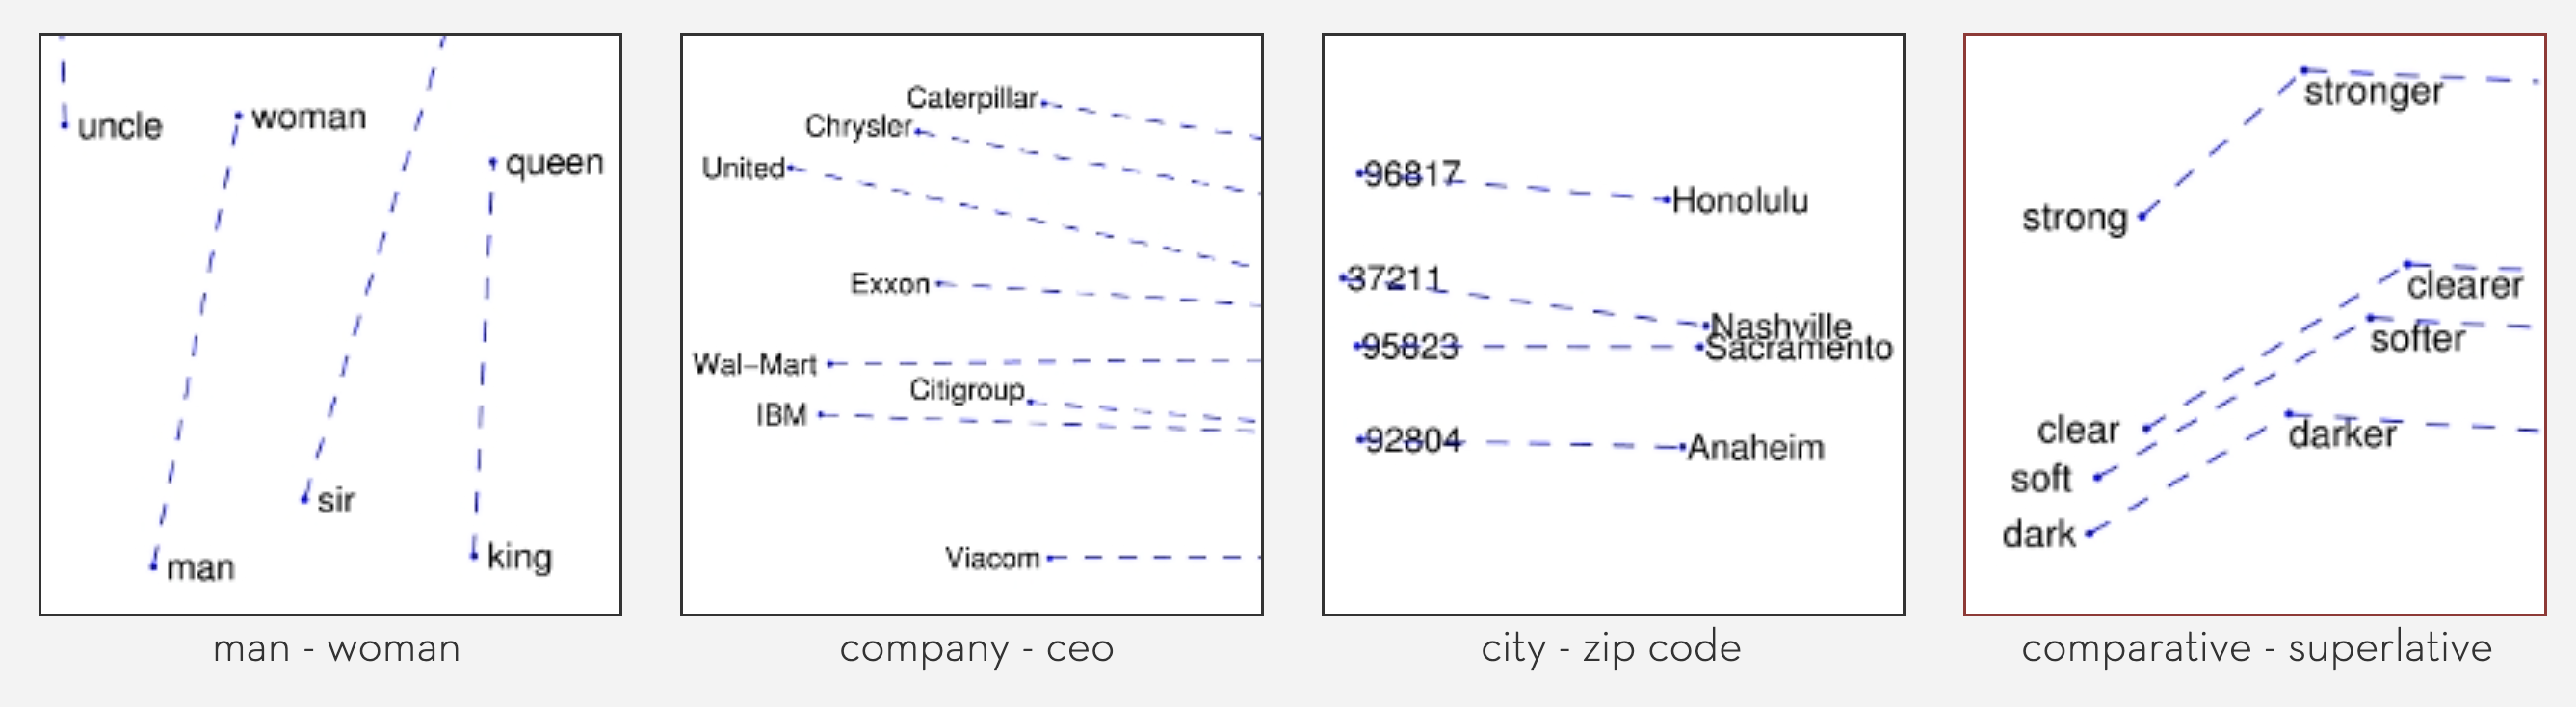

In [10]:
# Classic analogy: king - man + woman = ? (from scratch)
print("Analogy: king - man + woman = ?")
results = analogy(glove, positive=['king', 'woman'], negative=['man'])
for word, score in results:
    print(f"  {word:15s} {score:.4f}")

print("\nAnalogy: paris - france + germany = ?")
results = analogy(glove, positive=['paris', 'germany'], negative=['france'])
for word, score in results:
    print(f"  {word:15s} {score:.4f}")

Analogy: king - man + woman = ?
  queen           0.8610
  daughter        0.7685
  prince          0.7641
  throne          0.7635
  princess        0.7513

Analogy: paris - france + germany = ?
  berlin          0.9181
  frankfurt       0.8184
  munich          0.8121
  vienna          0.8101
  hamburg         0.7974


In [11]:
# Odd-one-out
print("Which word doesn't match? ['breakfast', 'lunch', 'dinner', 'computer']")
print(f"  Answer: {glove.doesnt_match(['breakfast', 'lunch', 'dinner', 'computer'])}")

print("\nWhich word doesn't match? ['cat', 'dog', 'fish', 'car']")
print(f"  Answer: {glove.doesnt_match(['cat', 'dog', 'fish', 'car'])}")

Which word doesn't match? ['breakfast', 'lunch', 'dinner', 'computer']
  Answer: computer

Which word doesn't match? ['cat', 'dog', 'fish', 'car']
  Answer: car


### Shortcomings & Failures of GloVe

Understanding where embeddings **fail** is just as important as understanding where they succeed.

In [12]:
# --- Shortcoming 1: No OOV (Out-of-Vocabulary) handling ---
print("=== No OOV Handling ===")
print("Trying to look up 'compputer' (misspelled)...")
try:
    vec = glove['compputer']
    print(f"  Found vector: {vec[:5]}")
except KeyError as e:
    print(f"  KeyError! GloVe cannot handle misspelled/rare words: {e}")

print("\nTrying 'cryptocurrency' (may not be in older training data)...")
try:
    vec = glove['cryptocurrency']
    print(f"  Found vector (first 5 dims): {vec[:5]}")
except KeyError as e:
    print(f"  KeyError! Not in vocabulary: {e}")

=== No OOV Handling ===
Trying to look up 'compputer' (misspelled)...
  KeyError! GloVe cannot handle misspelled/rare words: "Key 'compputer' not present"

Trying 'cryptocurrency' (may not be in older training data)...
  KeyError! Not in vocabulary: "Key 'cryptocurrency' not present"


In [13]:
# --- Shortcoming 2: Static embeddings (polysemy problem) ---
print("=== Static Embeddings — Polysemy Problem ===")
print("\nThe word 'bank' has multiple meanings (financial institution vs river bank).")
print("GloVe assigns ONE vector regardless of context.\n")
print("Top 10 neighbors of 'bank':")
for word, score in most_similar(glove, 'bank'):
    # Tag likely sense
    print(f"  {word:15s} {score:.4f}")

=== Static Embeddings — Polysemy Problem ===

The word 'bank' has multiple meanings (financial institution vs river bank).
GloVe assigns ONE vector regardless of context.

Top 10 neighbors of 'bank':
  banks           0.8699
  securities      0.7997
  banking         0.7965
  investment      0.7850
  exchange        0.7809
  financial       0.7670
  credit          0.7649
  lender          0.7518
  capital         0.7381
  brokerage       0.7374


In [14]:
# --- Shortcoming 3: Frequency bias ---
print("=== Frequency Bias ===")
print("Common function words cluster together despite having no semantic relationship:\n")
function_word_pairs = [('the', 'of'), ('the', 'and'), ('is', 'was'), ('in', 'at')]
semantic_pairs = [('cat', 'dog'), ('king', 'queen'), ('happy', 'sad')]

print("Function word pairs (should be LOW similarity — they're semantically vacuous):")
for w1, w2 in function_word_pairs:
    sim = cosine_sim(glove[w1], glove[w2])
    print(f"  sim('{w1}', '{w2}') = {sim:.4f}")

print("\nSemantic word pairs (should be HIGH similarity):")
for w1, w2 in semantic_pairs:
    sim = cosine_sim(glove[w1], glove[w2])
    print(f"  sim('{w1}', '{w2}') = {sim:.4f}")

print("Function words often have HIGHER similarity than semantically related pairs!")

=== Frequency Bias ===
Common function words cluster together despite having no semantic relationship:

Function word pairs (should be LOW similarity — they're semantically vacuous):
  sim('the', 'of') = 0.9026
  sim('the', 'and') = 0.8326
  sim('is', 'was') = 0.7405
  sim('in', 'at') = 0.8209

Semantic word pairs (should be HIGH similarity):
  sim('cat', 'dog') = 0.9218
  sim('king', 'queen') = 0.7839
  sim('happy', 'sad') = 0.6891
Function words often have HIGHER similarity than semantically related pairs!


In [15]:
# --- Shortcoming 4: Analogy failures ---
print("=== Analogy Failures ===\n")

analogies = [
    (['bigger', 'small'], ['big'], "'bigger' - 'big' + 'small' = 'smaller'?"),
    (['doctor', 'woman'], ['man'], "'doctor' - 'man' + 'woman' = ? (gender bias check)"),
    (['good', 'evil'], ['bad'], "'good' - 'bad' + 'evil' = ?"),
]

for pos, neg, description in analogies:
    results = analogy(glove, pos, neg)
    print(f"Analogy: {description}")
    for w, s in results:
        print(f"  {w:15s} {s:.4f}")
    print()

=== Analogy Failures ===

Analogy: 'bigger' - 'big' + 'small' = 'smaller'?
  larger          0.9044
  large           0.8707
  smaller         0.8655
  normally        0.7709
  typically       0.7661

Analogy: 'doctor' - 'man' + 'woman' = ? (gender bias check)
  nurse           0.8424
  child           0.7754
  pregnant        0.7679
  mother          0.7661
  patient         0.7491

Analogy: 'good' - 'bad' + 'evil' = ?
  spirit          0.7932
  true            0.7670
  god             0.7602
  essence         0.7218
  beings          0.7142



### Exercise 1: Exploring Word Similarities

**Task:** Choose 5 *related* word pairs and 5 *unrelated* word pairs. Compute cosine similarity for each pair using the GloVe model.

Reflect on the output

**Expected output:** A pandas DataFrame with columns: `word1`, `word2`, `related`, `cosine_similarity`, sorted by similarity.

In [16]:
# Exercise 1: Your code here

# TODO: Define 5 related pairs and 5 unrelated pairs
related_pairs = [
    # ('word1', 'word2'),  # example
    # TODO: add 5 related pairs
]

unrelated_pairs = [
    # ('word1', 'word2'),  # example
    # TODO: add 5 unrelated pairs
]

# TODO: Compute cosine similarity for each pair using the cosine_sim helper
# TODO: Sort by cosine_similarity descending and display

In [17]:
# @title Solution — Exercise 1 (click to expand)

related_pairs = [
    ('cat', 'dog'),
    ('king', 'queen'),
    ('happy', 'joyful'),
    ('car', 'vehicle'),
    ('doctor', 'nurse'),
]

unrelated_pairs = [
    ('cat', 'democracy'),
    ('king', 'banana'),
    ('happy', 'triangle'),
    ('car', 'philosophy'),
    ('doctor', 'guitar'),
]

rows = []
for w1, w2 in related_pairs:
    sim = cosine_sim(glove[w1], glove[w2])
    rows.append({'word1': w1, 'word2': w2, 'related': True, 'cosine_similarity': round(sim, 4)})

for w1, w2 in unrelated_pairs:
    sim = cosine_sim(glove[w1], glove[w2])
    rows.append({'word1': w1, 'word2': w2, 'related': False, 'cosine_similarity': round(sim, 4)})

df_ex1 = pd.DataFrame(rows).sort_values('cosine_similarity', ascending=False)
print(df_ex1.to_string(index=False))

assert len(related_pairs) == 5, "Need exactly 5 related pairs"
assert len(unrelated_pairs) == 5, "Need exactly 5 unrelated pairs"
print("\n✓ Exercise 1 complete. Related pairs generally have higher similarity, but not always!")

 word1      word2  related  cosine_similarity
   cat        dog     True             0.9218
   car    vehicle     True             0.8834
doctor      nurse     True             0.7977
  king      queen     True             0.7839
 happy     joyful     True             0.5550
doctor     guitar    False             0.2801
  king     banana    False             0.2207
 happy   triangle    False             0.0865
   car philosophy    False             0.0427
   cat  democracy    False             0.0368

✓ Exercise 1 complete. Related pairs generally have higher similarity, but not always!


#### When Metrics Disagree

In [18]:
# Show cases where cosine and Euclidean disagree
print("=== When Metrics Disagree ===\n")
test_pairs = [
    ('king', 'queen'),
    ('the', 'of'),
    ('cat', 'dog'),
    ('happy', 'sad'),
    ('big', 'small'),
    ('computer', 'algorithm'),
]

rows = []
for w1, w2 in test_pairs:
    v1, v2 = glove[w1], glove[w2]
    rows.append({
        'pair': f"({w1}, {w2})",
        'cosine_sim': round(cosine_sim(v1, v2), 4),
        'euclidean_dist': round(euclidean_dist(v1, v2), 4),
        'dot_product': round(dot_product(v1, v2), 4),
        'norm_w1': round(np.linalg.norm(v1), 4),
        'norm_w2': round(np.linalg.norm(v2), 4),
    })

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))
print("\nNote: 'the'/'of' have high cosine similarity AND large norms (frequent words).")
print("  Dot product is inflated by magnitude; cosine normalizes it away.")
print("  Euclidean distance can be large even for similar words if their magnitudes differ.")

=== When Metrics Disagree ===

                 pair  cosine_sim  euclidean_dist  dot_product  norm_w1  norm_w2
        (king, queen)      0.7839          3.4778    21.877501   5.3745   5.1928
            (the, of)      0.9026          2.1897    22.223801   4.9678   4.9561
           (cat, dog)      0.9218          1.8846    19.739100   4.4079   4.8580
         (happy, sad)      0.6891          3.8400    16.146700   4.6372   5.0532
         (big, small)      0.7008          4.0109    18.838499   5.2184   5.1510
(computer, algorithm)      0.3613          6.6202    12.387300   5.9531   5.7586

Note: 'the'/'of' have high cosine similarity AND large norms (frequent words).
  Dot product is inflated by magnitude; cosine normalizes it away.
  Euclidean distance can be large even for similar words if their magnitudes differ.


#### Analogy Arithmetic & Parallelogram Plots

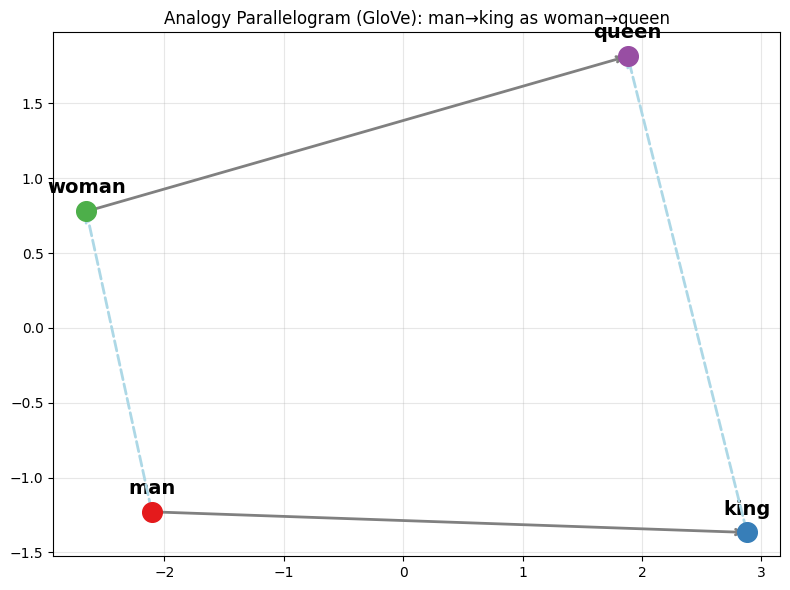

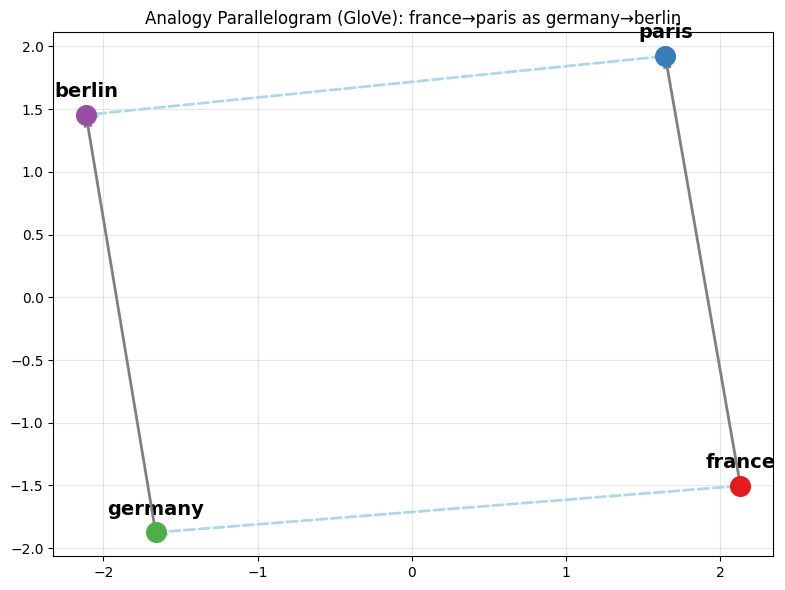

In [19]:
# Classic analogy visualization: king - man + woman = queen
def plot_analogy_parallelogram(w1, w2, w3, w4, model, model_name, dim_reducer='pca'):
    """Plot the analogy parallelogram: w1 is to w2 as w3 is to w4."""
    words = [w1, w2, w3, w4]
    vecs = np.array([model[w] for w in words])

    if dim_reducer == 'pca':
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, perplexity=3, random_state=SEED)
    vecs_2d = reducer.fit_transform(vecs)

    fig, ax = plt.subplots(figsize=(8, 6))
    # Plot points
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    for i, (word, color) in enumerate(zip(words, colors)):
        ax.scatter(vecs_2d[i, 0], vecs_2d[i, 1], c=color, s=200, zorder=5)
        ax.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]),
                    fontsize=14, fontweight='bold', ha='center', va='bottom',
                    xytext=(0, 10), textcoords='offset points')

    # Draw parallelogram edges
    # w1 -> w2, w3 -> w4 (analogous pairs)
    ax.annotate('', xy=vecs_2d[1], xytext=vecs_2d[0],
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))
    ax.annotate('', xy=vecs_2d[3], xytext=vecs_2d[2],
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))
    # w1 -> w3, w2 -> w4 (offset pairs)
    ax.annotate('', xy=vecs_2d[2], xytext=vecs_2d[0],
                arrowprops=dict(arrowstyle='->', color='lightblue', lw=2, linestyle='--'))
    ax.annotate('', xy=vecs_2d[3], xytext=vecs_2d[1],
                arrowprops=dict(arrowstyle='->', color='lightblue', lw=2, linestyle='--'))

    ax.set_title(f"Analogy Parallelogram ({model_name}): {w1}→{w2} as {w3}→{w4}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_analogy_parallelogram('man', 'king', 'woman', 'queen', glove, 'GloVe')
plot_analogy_parallelogram('france', 'paris', 'germany', 'berlin', glove, 'GloVe')

#### Where Geometry Breaks Down

This is critical for an honest understanding of word embeddings. The clean geometric picture is an approximation.

In [20]:
# --- The Parallelogram is a Myth ---
print("=== The Parallelogram Myth ===\n")
print("Even for 'working' analogies, the offset vectors are NOT parallel.\n")

analogy_pairs = [
    ('man', 'woman', 'king', 'queen'),
    ('france', 'paris', 'germany', 'berlin'),
    ('slow', 'slower', 'fast', 'faster'),
    ('big', 'bigger', 'small', 'smaller'),
    ('man', 'woman', 'boy', 'girl'),
    ('walk', 'walked', 'run', 'ran'),
    ('berlin', 'germany', 'paris', 'france'),
    ('good', 'better', 'bad', 'worse'),
    ('king', 'kings', 'queen', 'queens'),
    ('cat', 'cats', 'dog', 'dogs'),
]

print(f"{'Analogy':<40} {'Cosine of offsets':<18} {'Angle (°)':<10}")
print("-" * 70)
for w1, w2, w3, w4 in analogy_pairs:
    try:
        offset_a = glove[w2] - glove[w1]
        offset_b = glove[w4] - glove[w3]
        cos = cosine_sim(offset_a, offset_b)
        angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))
        print(f"  ({w1}→{w2}) vs ({w3}→{w4}){'':<15} {cos:>8.4f}        {angle:>6.1f}°")
    except KeyError as e:
        print(f"  Skipped ({w1}→{w2}) vs ({w3}→{w4}): {e}")

print("\nPerfect parallelism would be 0°. Most 'working' analogies are 20-60° off!")

=== The Parallelogram Myth ===

Even for 'working' analogies, the offset vectors are NOT parallel.

Analogy                                  Cosine of offsets  Angle (°) 
----------------------------------------------------------------------
  (man→woman) vs (king→queen)                  0.5970          53.3°
  (france→paris) vs (germany→berlin)                  0.7957          37.3°
  (slow→slower) vs (fast→faster)                  0.5026          59.8°
  (big→bigger) vs (small→smaller)                  0.4518          63.1°
  (man→woman) vs (boy→girl)                  0.6695          48.0°
  (walk→walked) vs (run→ran)                  0.2837          73.5°
  (berlin→germany) vs (paris→france)                  0.7957          37.3°
  (good→better) vs (bad→worse)                  0.4621          62.5°
  (king→kings) vs (queen→queens)                  0.5698          55.3°
  (cat→cats) vs (dog→dogs)                  0.7399          42.3°

Perfect parallelism would be 0°. Most 'working' 

In [21]:
# --- Cosine Similarity Paradoxes ---
print("=== Cosine Similarity Paradoxes ===\n")

paradox_examples = [
    ('hot', 'cold', "Antonyms — high similarity because they share contexts"),
    ('good', 'bad', "Antonyms — distributional similarity ≠ semantic similarity"),
    ('good', 'excellent', "Synonyms — may be LESS similar than antonyms!"),
    ('man', 'woman', "Opposites on one dimension but similar overall"),
    ('happy', 'sad', "Antonyms in similar contexts"),
    ('happy', 'joyful', "Near-synonyms"),
]

print(f"{'Pair':<25} {'Cosine Sim':<12} {'Note'}")
print("-" * 80)
for w1, w2, note in paradox_examples:
    sim = cosine_sim(glove[w1], glove[w2])
    print(f"  ({w1}, {w2}){'':<10} {sim:>8.4f}     {note}")

print("\nDistributional similarity captures co-occurrence, not true semantic meaning.")

=== Cosine Similarity Paradoxes ===

Pair                      Cosine Sim   Note
--------------------------------------------------------------------------------
  (hot, cold)             0.8011     Antonyms — high similarity because they share contexts
  (good, bad)             0.7965     Antonyms — distributional similarity ≠ semantic similarity
  (good, excellent)             0.8062     Synonyms — may be LESS similar than antonyms!
  (man, woman)             0.8860     Opposites on one dimension but similar overall
  (happy, sad)             0.6891     Antonyms in similar contexts
  (happy, joyful)             0.5550     Near-synonyms

Distributional similarity captures co-occurrence, not true semantic meaning.


In [22]:
# --- Social Biases Encoded in Geometry ---
print("=== Social Biases in Word Embeddings ===\n")

# Gender direction
gender_direction = glove['man'] - glove['woman']
gender_direction = gender_direction / np.linalg.norm(gender_direction)

# Project profession words onto gender axis
professions = ['doctor', 'nurse', 'engineer', 'teacher', 'scientist', 'secretary',
               'programmer', 'homemaker', 'professor', 'receptionist',
               'architect', 'librarian', 'pilot', 'dancer', 'surgeon', 'nanny']

projections = []
for prof in professions:
    if prof in glove:
        proj = np.dot(glove[prof], gender_direction)
        projections.append((prof, proj))

projections.sort(key=lambda x: x[1])

print("Profession projections onto (man - woman) direction:")
print("More 'woman'-associated                More 'man'-associated →\n")
for prof, proj in projections:
    bar_len = int((proj + 0.5) * 40)
    bar = '█' * max(0, bar_len)
    print(f"  {prof:15s} {proj:+.4f} |{bar}")

print("\nThese biases come from the training data (Wikipedia + Gigaword).")
print("They reflect societal stereotypes, NOT truth about professions.")

=== Social Biases in Word Embeddings ===

Profession projections onto (man - woman) direction:
More 'woman'-associated                More 'man'-associated →

  nurse           -1.8750 |
  homemaker       -1.7259 |
  nanny           -1.3025 |
  receptionist    -1.2799 |
  librarian       -0.9619 |
  dancer          -0.9396 |
  teacher         -0.9166 |
  surgeon         -0.8541 |
  doctor          -0.5834 |
  professor       -0.0605 |█████████████████
  pilot           -0.0050 |███████████████████
  scientist       +0.2693 |██████████████████████████████
  programmer      +0.2698 |██████████████████████████████
  engineer        +0.4001 |████████████████████████████████████
  secretary       +0.8829 |███████████████████████████████████████████████████████
  architect       +0.9719 |██████████████████████████████████████████████████████████

These biases come from the training data (Wikipedia + Gigaword).
They reflect societal stereotypes, NOT truth about professions.


In [23]:
# --- t-SNE projection can be misleading ---
print("=== t-SNE Projection Illusions ===\n")

# Pick 20 words and find pairs that look close in t-SNE but aren't in original space
demo_words = ['king', 'queen', 'man', 'woman', 'cat', 'dog', 'computer',
              'happy', 'sad', 'car', 'france', 'paris', 'red', 'blue',
              'music', 'food', 'water', 'fire', 'love', 'money']
demo_vecs = np.array([glove[w] for w in demo_words])

tsne_demo = TSNE(n_components=2, perplexity=5, random_state=SEED)
demo_2d = tsne_demo.fit_transform(demo_vecs)

# Find biggest discrepancy: close in 2D but far in original space
discrepancies = []
for i in range(len(demo_words)):
    for j in range(i+1, len(demo_words)):
        dist_2d = euclidean_dist(demo_2d[i], demo_2d[j])
        cos_orig = cosine_sim(demo_vecs[i], demo_vecs[j])
        discrepancies.append((demo_words[i], demo_words[j], dist_2d, cos_orig))

# Sort by smallest 2D distance and show those with low original cosine
discrepancies.sort(key=lambda x: x[2])
print("Pairs CLOSE in t-SNE 2D projection but with varying original cosine similarity:")
print(f"{'Pair':<25} {'t-SNE dist':<12} {'Original cosine':<15}")
print("-" * 55)
for w1, w2, d2d, cos_orig in discrepancies[:10]:
    flag = "misleading!" if cos_orig < 0.3 else ""
    print(f"  ({w1}, {w2}){'':<8} {d2d:>8.2f}     {cos_orig:>8.4f}{flag}")

print("\nAlways verify patterns you see in t-SNE against original-space metrics!")

=== t-SNE Projection Illusions ===

Pairs CLOSE in t-SNE 2D projection but with varying original cosine similarity:
Pair                      t-SNE dist   Original cosine
-------------------------------------------------------
  (france, paris)            10.52       0.8025
  (cat, dog)            10.78       0.9218
  (man, woman)            10.86       0.8860
  (king, queen)            10.86       0.7839
  (red, blue)            10.97       0.8902
  (happy, love)            12.04       0.7997
  (food, water)            12.19       0.7006
  (car, fire)            13.69       0.6417
  (happy, sad)            14.65       0.6891
  (music, love)            16.62       0.6578

Always verify patterns you see in t-SNE against original-space metrics!


### Exercise 2: Metric Exploration & Analogy Analysis

**Tasks:**
1. **(a)** Generate 20 random word pairs. Compute all 3 metrics. Create 3 scatter plots showing metric correlations.
2. **(b)** Find 3 *working* and 3 *failing* analogies. Produce parallelogram plots for each.
3. **(c)** For 10 analogy pairs, compute the angle between offset vectors. How far from parallel are they?

In [24]:
# Exercise 2: Your code here

# TODO (a): 20 random word pairs, 3 metrics, scatter plots
# TODO (b): 3 working + 3 failing analogies, parallelogram plots
# TODO (c): 10 analogy pairs, angle between offset vectors

In [25]:
# @title Solution — Exercise 2 (click to expand)

# --- Part (a): Metric correlations ---
# np.random.seed(SEED)
# vocab_words = list(glove.index_to_key[:5000])
# random_indices = np.random.choice(len(vocab_words), size=(20, 2), replace=False)
# random_pairs = [(vocab_words[i], vocab_words[j]) for i, j in random_indices]

# metrics_data = []
# for w1, w2 in random_pairs:
#     v1, v2 = glove[w1], glove[w2]
#     metrics_data.append({
#         'pair': f"({w1}, {w2})",
#         'cosine': cosine_sim(v1, v2),
#         'euclidean': euclidean_dist(v1, v2),
#         'dot': dot_product(v1, v2),
#     })

# df_metrics = pd.DataFrame(metrics_data)

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# axes[0].scatter(df_metrics['cosine'], df_metrics['euclidean'], alpha=0.7)
# axes[0].set_xlabel('Cosine Similarity'); axes[0].set_ylabel('Euclidean Distance')
# axes[0].set_title('Cosine vs Euclidean')

# axes[1].scatter(df_metrics['cosine'], df_metrics['dot'], alpha=0.7)
# axes[1].set_xlabel('Cosine Similarity'); axes[1].set_ylabel('Dot Product')
# axes[1].set_title('Cosine vs Dot Product')

# axes[2].scatter(df_metrics['euclidean'], df_metrics['dot'], alpha=0.7)
# axes[2].set_xlabel('Euclidean Distance'); axes[2].set_ylabel('Dot Product')
# axes[2].set_title('Euclidean vs Dot Product')

# plt.tight_layout()
# plt.show()

# # --- Part (b): Working and failing analogies ---
# print("\n=== Working Analogies ===")
# working = [
#     ('man', 'king', 'woman', 'queen'),
#     ('france', 'paris', 'germany', 'berlin'),
#     ('big', 'bigger', 'small', 'smaller'),
# ]
# for w1, w2, w3, w4 in working:
#     plot_analogy_parallelogram(w1, w2, w3, w4, glove, 'GloVe')

# print("\n=== Failing Analogies ===")
# failing = [
#     ('man', 'doctor', 'woman', 'nurse'),     # gender bias, not real analogy
#     ('walk', 'walked', 'swim', 'swam'),       # tense inconsistency
#     ('france', 'paris', 'nigeria', 'abuja'),  # under-represented
# ]
# for w1, w2, w3, w4 in failing:
#     try:
#         plot_analogy_parallelogram(w1, w2, w3, w4, glove, 'GloVe')
#     except KeyError as e:
#         print(f"  Skipped: {e}")

# # --- Part (c): Offset vector angles ---
# print("\n=== Offset Vector Angles ===")
# analogy_test = [
#     ('man', 'woman', 'king', 'queen'),
#     ('france', 'paris', 'germany', 'berlin'),
#     ('slow', 'slower', 'fast', 'faster'),
#     ('big', 'bigger', 'small', 'smaller'),
#     ('man', 'woman', 'boy', 'girl'),
#     ('walk', 'walked', 'run', 'ran'),
#     ('italy', 'rome', 'japan', 'tokyo'),
#     ('good', 'better', 'bad', 'worse'),
#     ('cat', 'cats', 'dog', 'dogs'),
#     ('come', 'came', 'go', 'went'),
# ]

# angles = []
# for w1, w2, w3, w4 in analogy_test:
#     try:
#         o1 = glove[w2] - glove[w1]
#         o2 = glove[w4] - glove[w3]
#         cos = cosine_sim(o1, o2)
#         angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))
#         angles.append(angle)
#         print(f"  ({w1}→{w2}) vs ({w3}→{w4}): {angle:.1f}°")
#     except KeyError as e:
#         print(f"  Skipped: {e}")

# print(f"\nMean angle: {np.mean(angles):.1f}° (0° would be perfect parallelism)")
# print("✓ Exercise 2 complete.")

## Word2Vec: Training from Scratch

**Word2Vec** learns word embeddings by training a shallow neural network on a prediction task:

- **Skip-gram:** Given a center word, predict context words  
- **CBOW (Continuous Bag of Words):** Given context words, predict the center word  


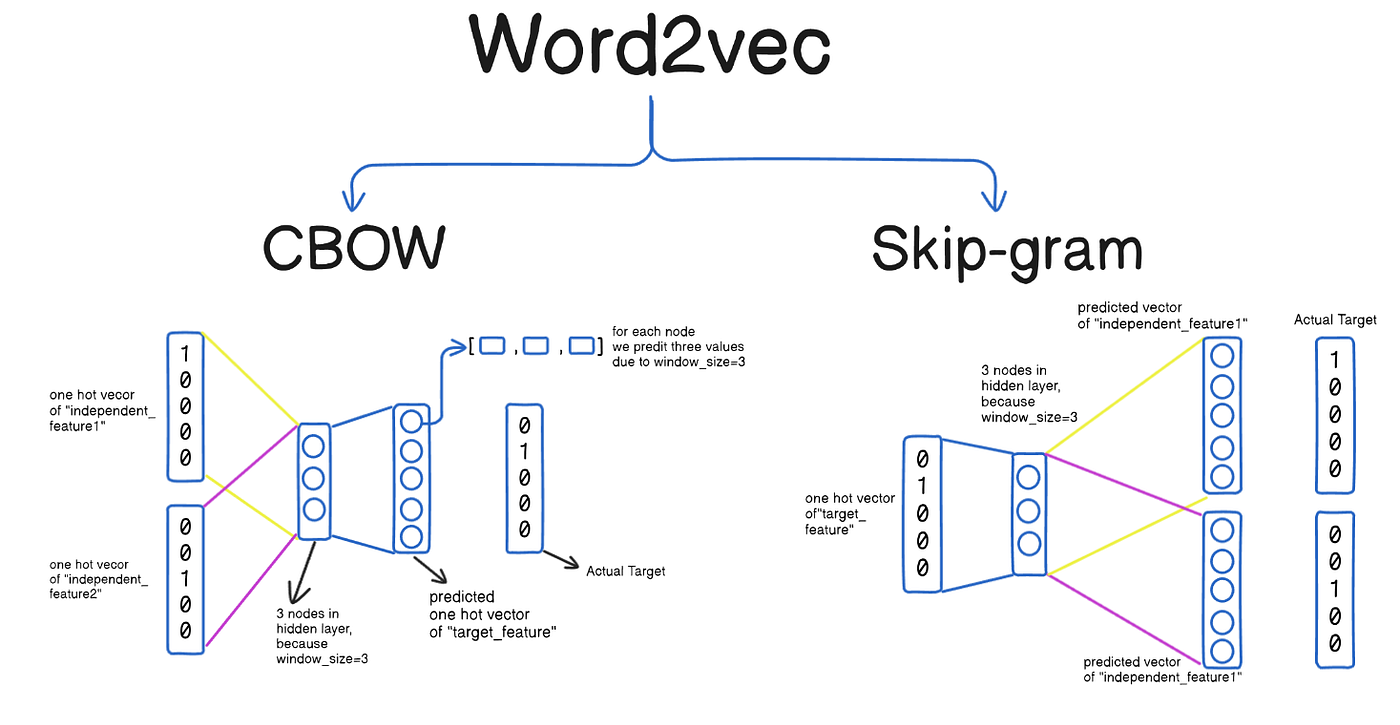
---

### Continuous Bag-of-words
Illustrations from https://github.com/OlgaChernytska/word2vec-pytorch
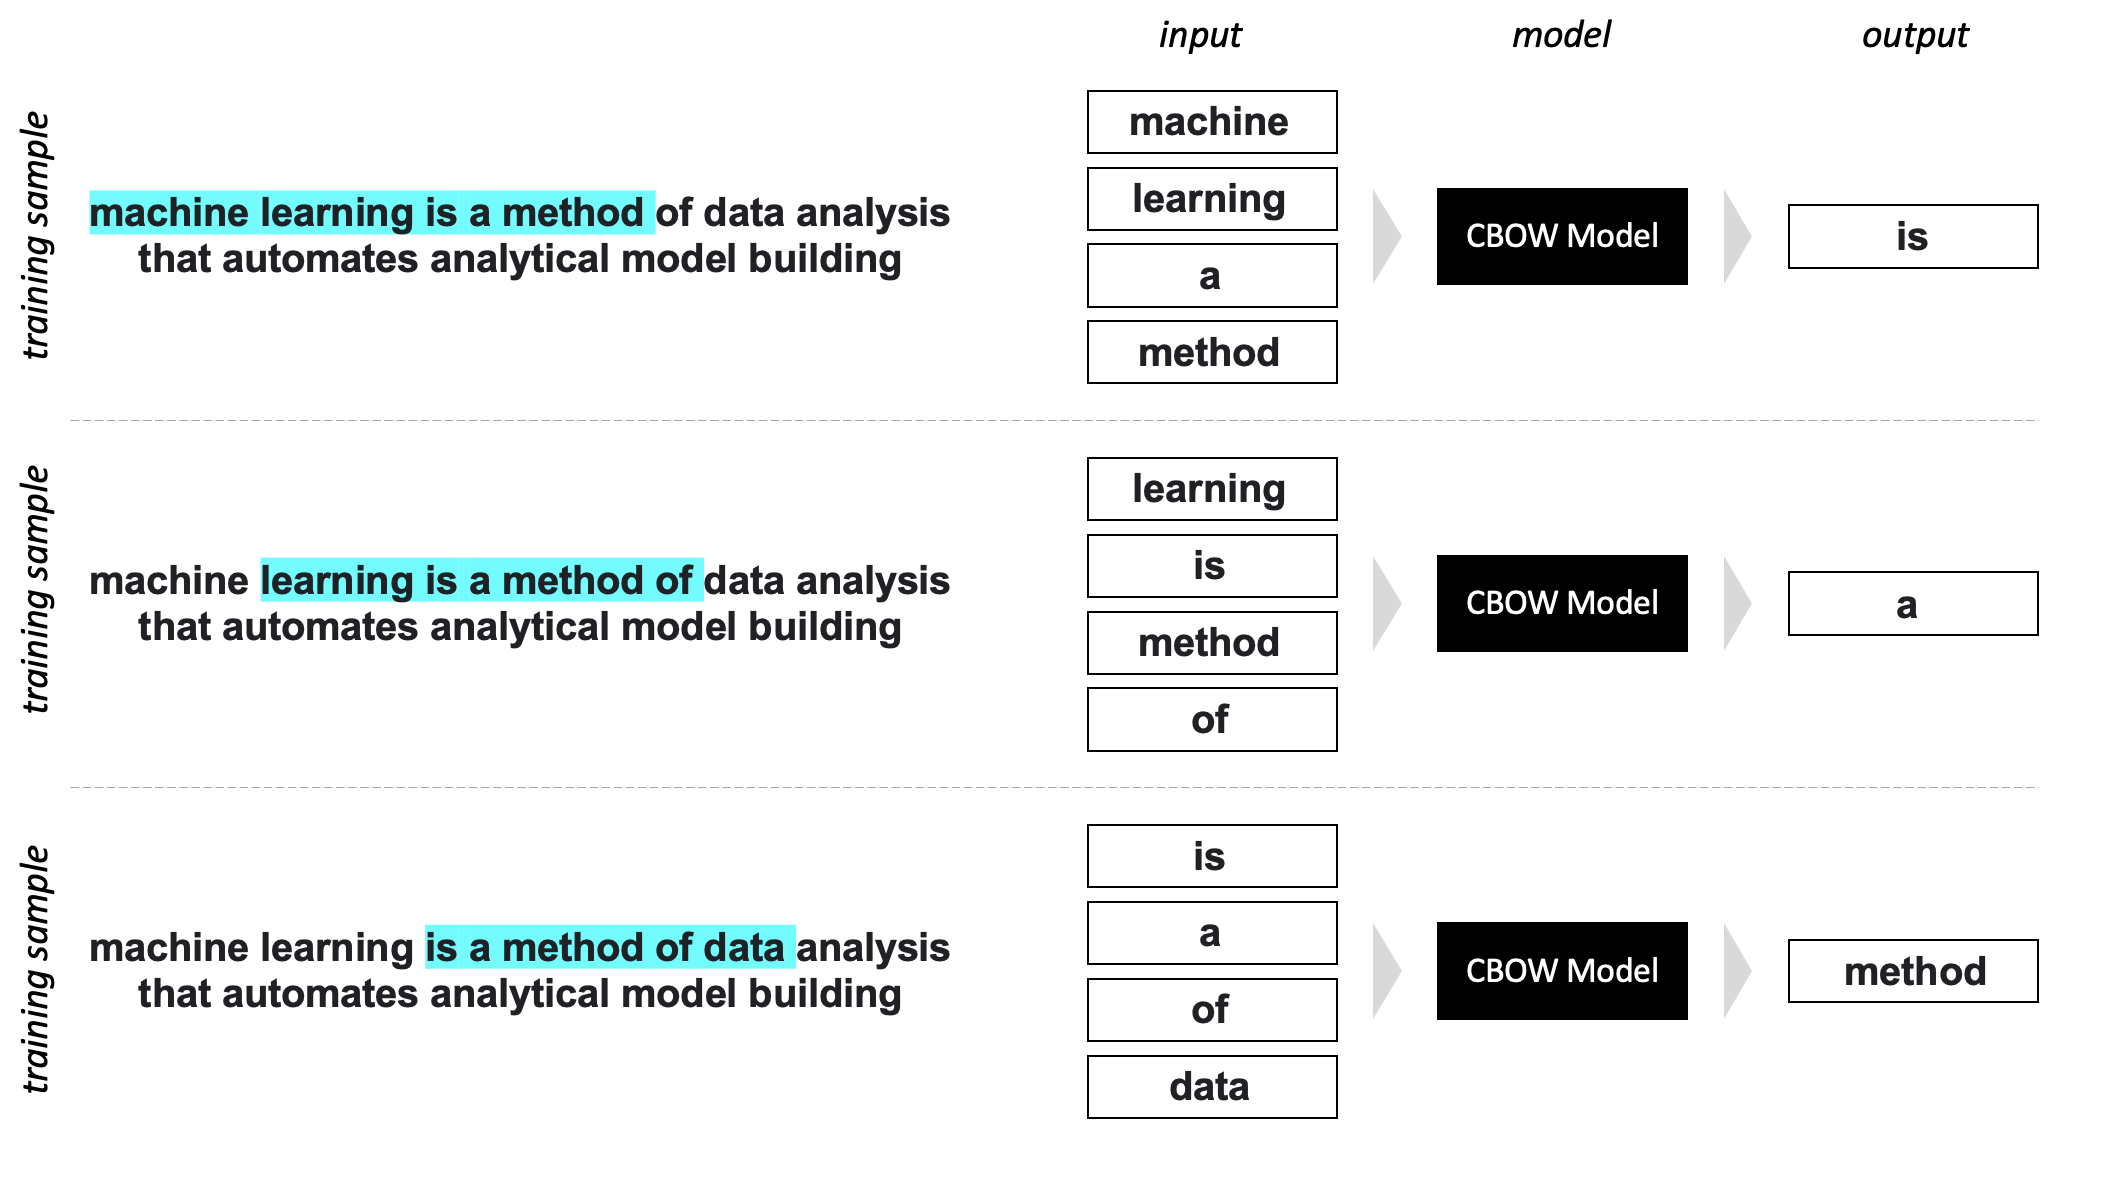


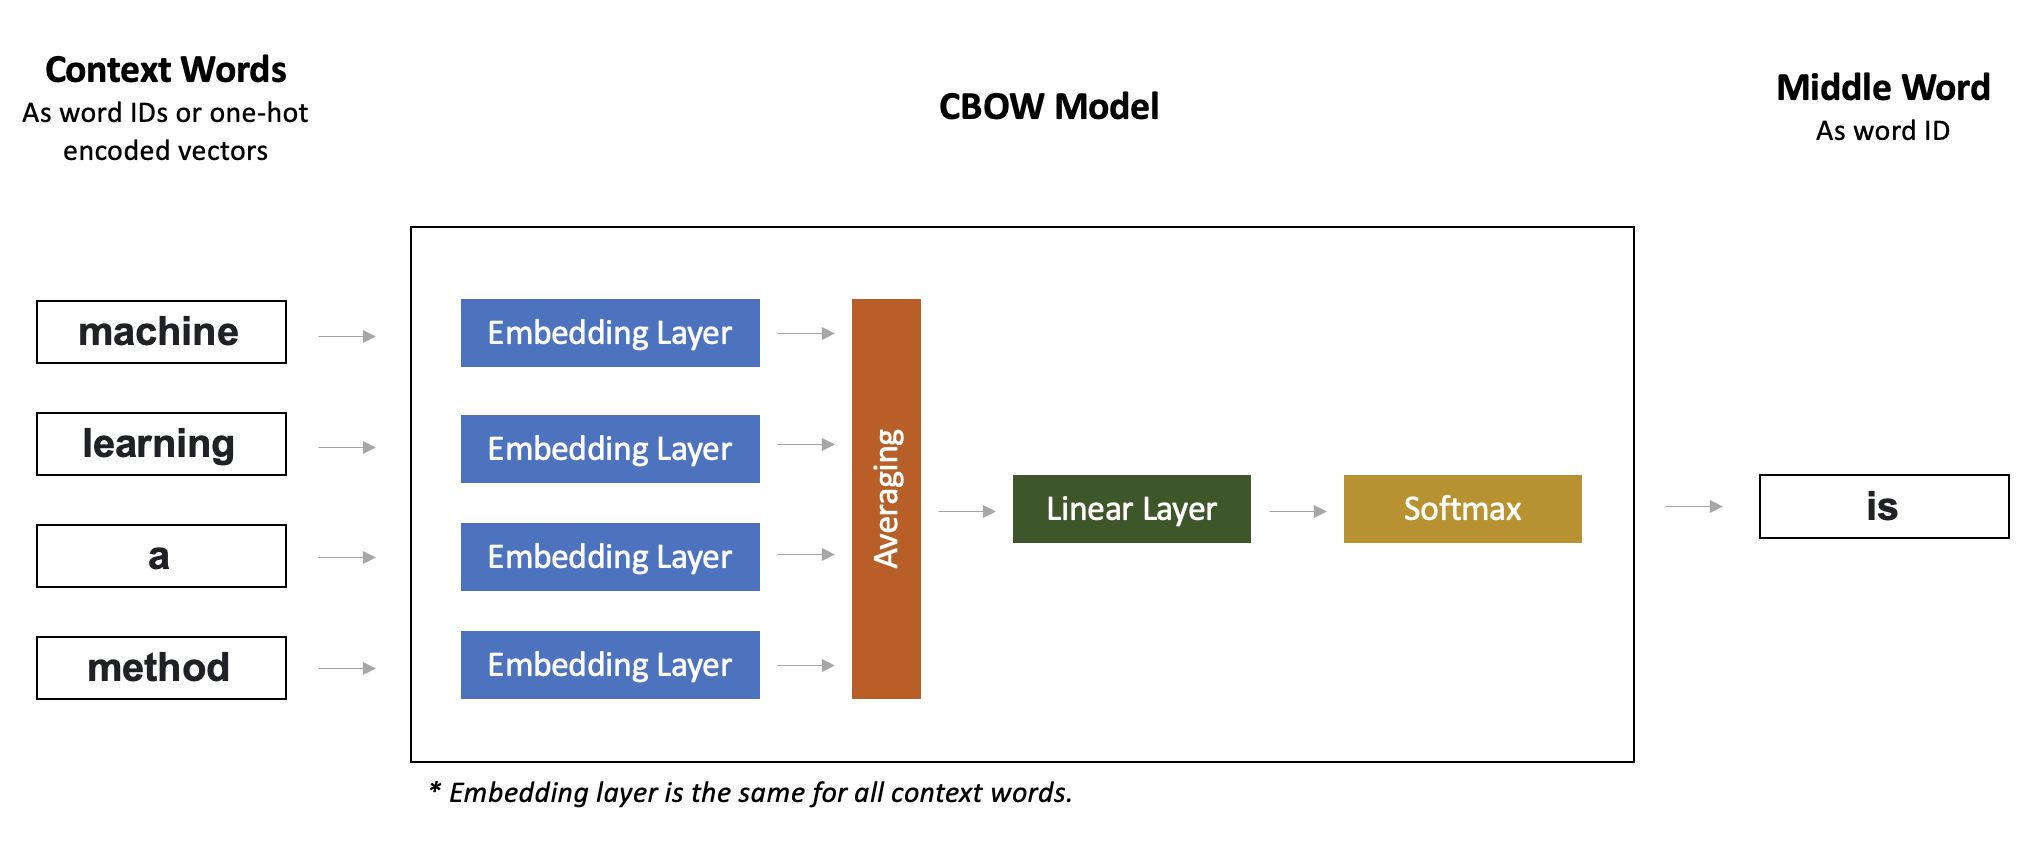


### Skip-gram
Illustrations from: https://github.com/OlgaChernytska/word2vec-pytorch

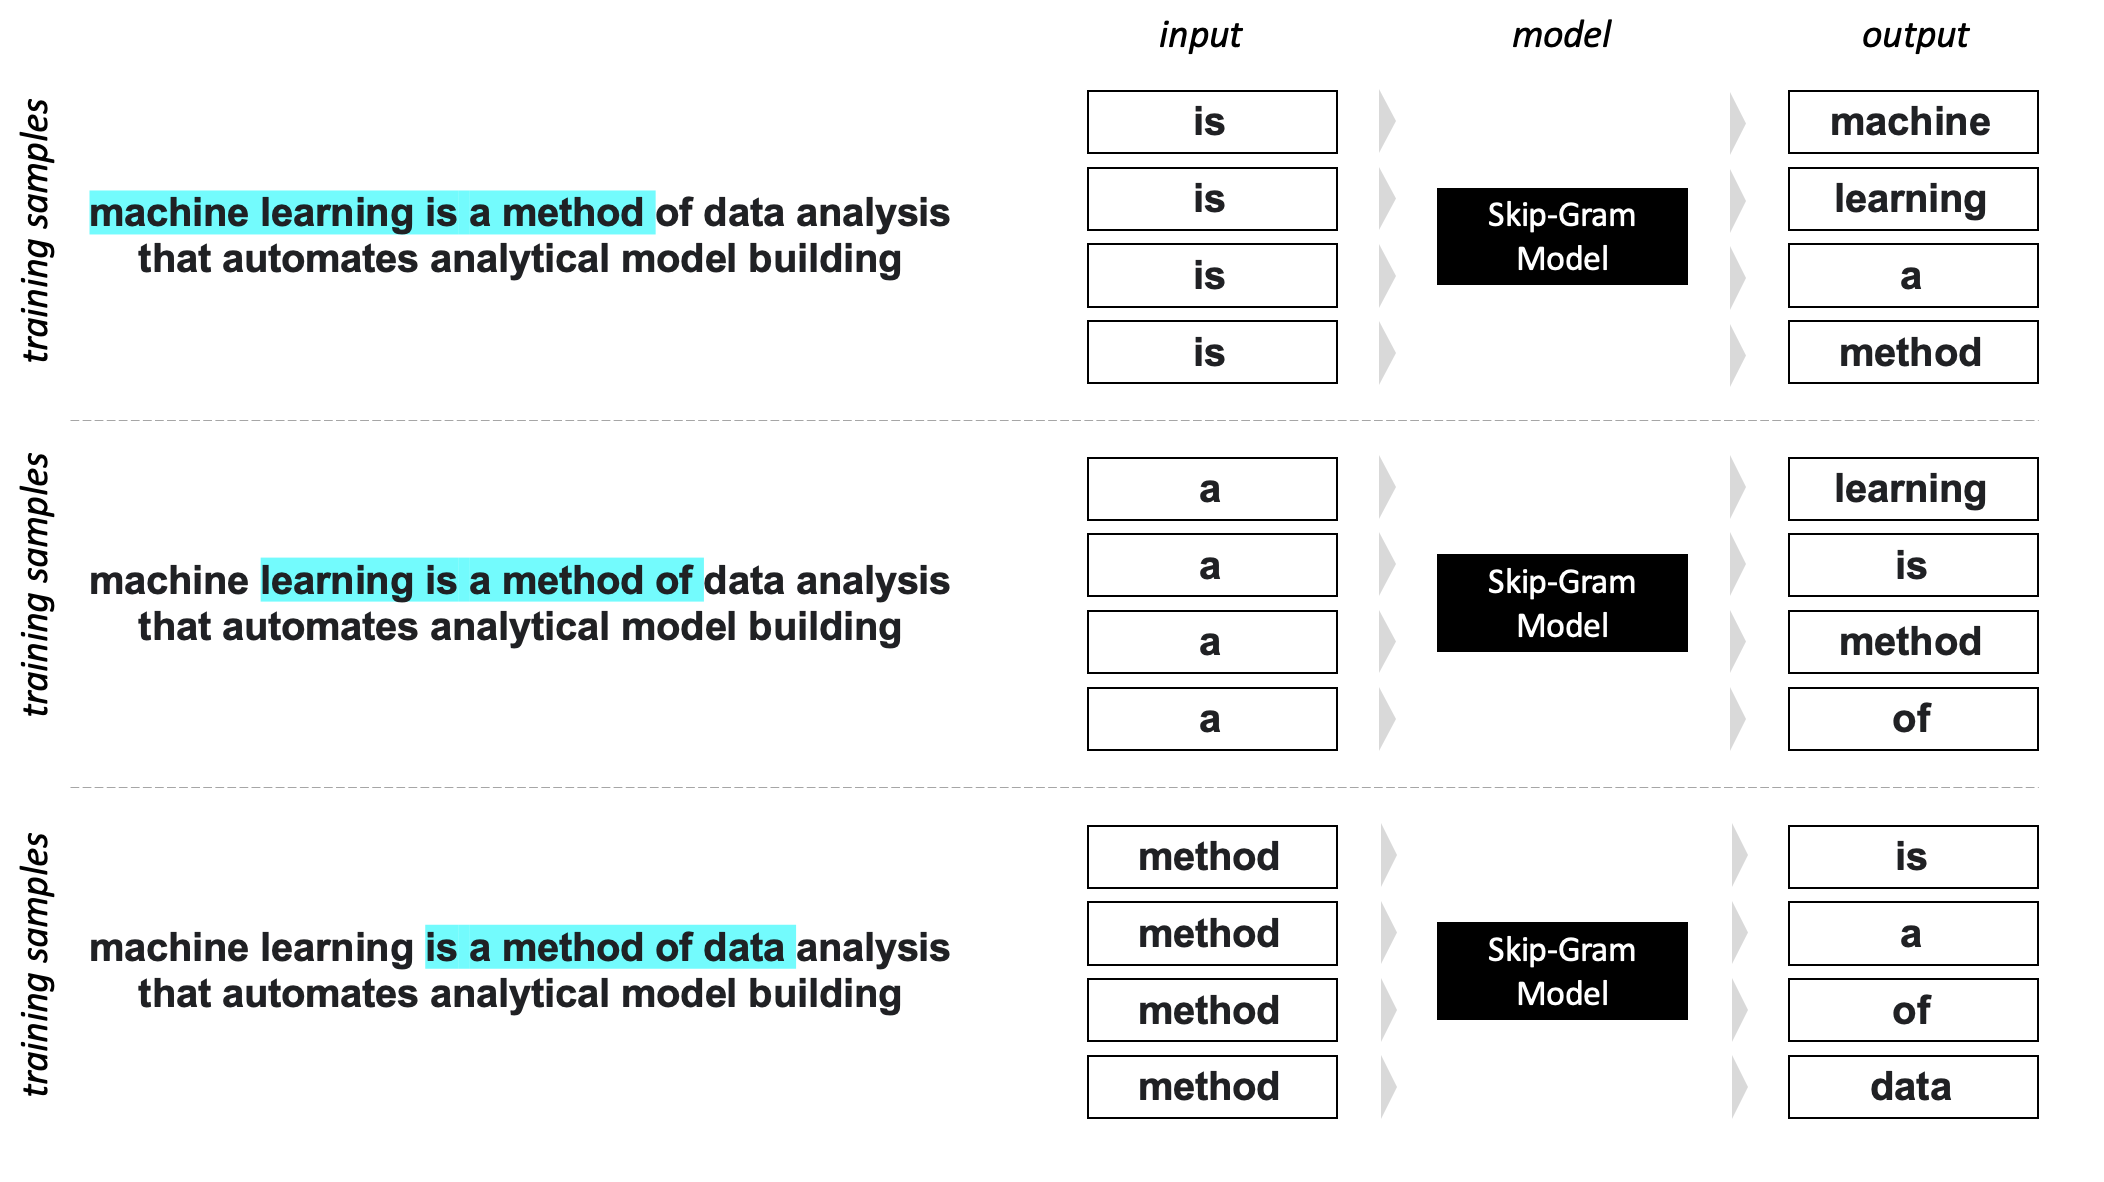

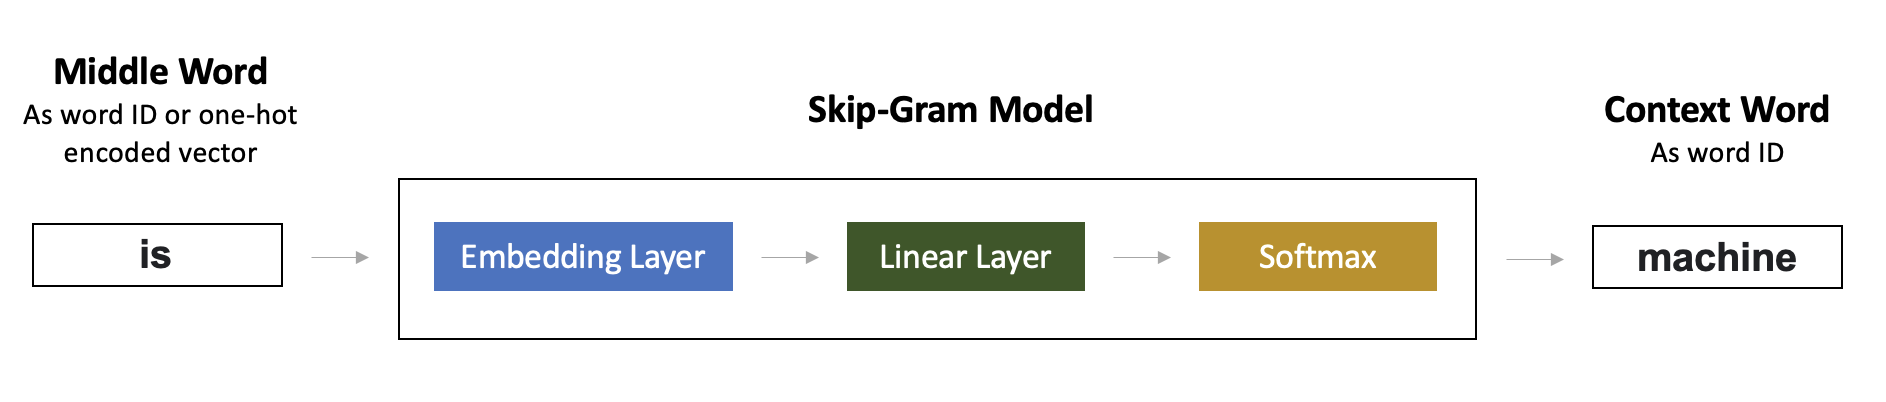

### Skip-gram Objective (Negative Sampling)



$$
J = \log \sigma(\mathbf{w}_O^T \mathbf{w}_I) +
\sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)}
\left[\log \sigma(-\mathbf{w}_i^T \mathbf{w}_I)\right]
$$

---

### Symbols

- **$\mathbf{w}_I$** – embedding of the **input (center) word**
- **$\mathbf{w}_O$** – embedding of the **true context word**
- **$\mathbf{w}_i$** – embedding of a **negative sample**
- **$k$** – number of negative samples
- **$P_n(w)$** – noise distribution used to sample negative words
- **$\sigma(x)$** – sigmoid function  

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$


The objective has two parts:

1. **Positive term**

   $$
   \log \sigma(\mathbf{w}_O^T \mathbf{w}_I)
   $$

   Encourages the **center word** and the **true context word** to have **similar embeddings** (large dot product).

2. **Negative sampling term**

   $$
   \log \sigma(-\mathbf{w}_i^T \mathbf{w}_I)
   $$

   Encourages **randomly sampled words** to have **dissimilar embeddings** from the center word.



- Real word–context pairs: **vectors move closer**
- Random word pairs: **vectors move apart**

This training process shapes the embedding space so that **semantically similar words end up near each other**.


### Key Hyperparameters

- `vector_size` – Embedding dimension (e.g., 100)
- `window` – Context window size
- `sg` – `1` = Skip-gram, `0` = CBOW
- `negative` – Number of negative samples
- `min_count` – Ignore words below this frequency

Paper: https://arxiv.org/pdf/1301.3781

In [26]:
# Load the text8 corpus (~17M tokens of cleaned Wikipedia text)
print("Downloading text8 corpus...")
text8_corpus = api.load('text8')
text8_data = list(text8_corpus)  # list of lists of tokens
total_tokens = sum(len(sent) for sent in text8_data)
print(f"Corpus: {len(text8_data)} sentences, {total_tokens:,} tokens")

print(text8_data[10][:20])


[==================================================] 100.0% 31.6/31.6MB downloaded
Corpus: 1701 sentences, 17,005,207 tokens
['study', 'the', 'surface', 'of', 'the', 'moon', 'astronomy', 'is', 'generally', 'thought', 'to', 'have', 'begun', 'in', 'ancient', 'babylon', 'by', 'the', 'persian', 'zoroastrian']


In [27]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import time
import os

class TrainingLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.loss_previous = 0
        self.start = time.time()

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        loss_now = loss - self.loss_previous
        self.loss_previous = loss

        print(f"Epoch {self.epoch} | Loss: {loss_now:.2f} | Time: {time.time()-self.start:.2f}s")

        self.epoch += 1
        self.start = time.time()


logger = TrainingLogger()

model_w2v = Word2Vec(
    sentences=text8_data,
    vector_size=50,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    seed=SEED,
    workers=os.cpu_count(),
    compute_loss=True,
    callbacks=[logger],
    batch_words=50000,
    epochs=3
)

Epoch 0 | Loss: 19372210.00 | Time: 29.94s
Epoch 1 | Loss: 14691174.00 | Time: 24.43s
Epoch 2 | Loss: 8685904.00 | Time: 23.20s


### Demos: Comparing to GloVe

In [28]:
# Same queries as GloVe
print("Words most similar to 'king' (Word2Vec):")
for word, score in model_w2v.wv.most_similar('king', topn=10):
    print(f"  {word:15s} {score:.4f}")

print("\nWords most similar to 'computer' (Word2Vec):")
for word, score in model_w2v.wv.most_similar('computer', topn=10):
    print(f"  {word:15s} {score:.4f}")

print("\nAnalogy: king - man + woman = ? (Word2Vec)")
results = model_w2v.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
for word, score in results:
    print(f"  {word:15s} {score:.4f}")

Words most similar to 'king' (Word2Vec):
  frederick       0.9047
  viii            0.8927
  alexius         0.8860
  judah           0.8811
  sigismund       0.8793
  prince          0.8792
  tsar            0.8790
  grandson        0.8761
  empress         0.8706
  augustus        0.8700

Words most similar to 'computer' (Word2Vec):
  graphics        0.8860
  digital         0.8806
  machine         0.8756
  computers       0.8632
  graphical       0.8572
  computing       0.8491
  hardware        0.8422
  interface       0.8380
  developer       0.8316
  console         0.8314

Analogy: king - man + woman = ? (Word2Vec)
  viii            0.8135
  empress         0.8118
  matilda         0.8044
  daughter        0.7952
  sigismund       0.7936


### Shortcomings of Word2Vec

In [29]:
# --- Shortcoming 1: No OOV handling (same as GloVe) ---
print("=== No OOV Handling ===")
try:
    model_w2v.wv['compputer']
except KeyError as e:
    print(f"KeyError on misspelled word: {e}")

# --- Shortcoming 2: No subword information ---
print("\n=== No Subword Information ===")
print("'run', 'running', 'runner' are completely independent tokens:")
for w in ['run', 'running', 'runner']:
    try:
        sim = cosine_sim(model_w2v.wv['run'], model_w2v.wv[w])
        print(f"  sim('run', '{w}') = {sim:.4f}")
    except KeyError:
        print(f"  '{w}' not in vocabulary")

=== No OOV Handling ===
KeyError on misspelled word: "Key 'compputer' not present"

=== No Subword Information ===
'run', 'running', 'runner' are completely independent tokens:
  sim('run', 'run') = 1.0000
  sim('run', 'running') = 0.8268
  sim('run', 'runner') = 0.5846


In [30]:
# --- Shortcoming 3: Small corpus = poor quality ---
print("=== Small Corpus → Poor Quality ===")
print("\nCompare neighbors for 'king':")
print("\nWord2Vec (text8, ~17M tokens):")
for w, s in model_w2v.wv.most_similar('king', topn=5):
    print(f"  {w:15s} {s:.4f}")
print("\nGloVe (6B tokens):")
for w, s in glove.most_similar('king', topn=5):
    print(f"  {w:15s} {s:.4f}")
print("\n→ GloVe (trained on 350x more data) generally gives more intuitive neighbors.")

=== Small Corpus → Poor Quality ===

Compare neighbors for 'king':

Word2Vec (text8, ~17M tokens):
  frederick       0.9047
  viii            0.8927
  alexius         0.8860
  judah           0.8811
  sigismund       0.8793

GloVe (6B tokens):
  prince          0.8236
  queen           0.7839
  ii              0.7746
  emperor         0.7736
  son             0.7667

→ GloVe (trained on 350x more data) generally gives more intuitive neighbors.


### Exercise 3: CBOW vs Skip-gram

**Task:**
1. Train a CBOW model on text8 with `window=10`, `vector_size=100`, same other hyperparameters
2. Compare cosine similarities for 5 word pairs across GloVe, Skip-gram, and CBOW
3. Present results as a DataFrame

**Hint:** Set `sg=0` for CBOW.

In [31]:
# Exercise 3: Your code here

# TODO: Train CBOW model
# model_cbow = Word2Vec(...)

# TODO: Define 5 word pairs to compare
# word_pairs = [('king', 'queen'), ...]

# TODO: Compute cosine similarity for each pair in each model (GloVe, Skip-gram, CBOW)

In [32]:
# @title Solution — Exercise 3 (click to expand)

# Train CBOW model
# print("Training CBOW model...")
# t0 = time.time()
# model_cbow = Word2Vec(
#     sentences=text8_data,
#     vector_size=100,
#     window=10,
#     min_count=5,
#     sg=0,            # CBOW
#     negative=5,
#     epochs=5,
#     seed=SEED,
#     workers=4,
# )
# print(f"Trained in {time.time()-t0:.1f}s")

# # Compare word pairs
# word_pairs = [
#     ('king', 'queen'),
#     ('man', 'woman'),
#     ('good', 'bad'),
#     ('cat', 'dog'),
#     ('france', 'paris'),
# ]

# rows = []
# for w1, w2 in word_pairs:
#     row = {'word1': w1, 'word2': w2}
#     # GloVe (50d)
#     row['glove_sim'] = round(cosine_sim(glove[w1], glove[w2]), 4)
#     # Skip-gram
#     row['skipgram_sim'] = round(cosine_sim(model_w2v.wv[w1], model_w2v.wv[w2]), 4)
#     # CBOW
#     row['cbow_sim'] = round(cosine_sim(model_cbow.wv[w1], model_cbow.wv[w2]), 4)
#     rows.append(row)

# df_ex2 = pd.DataFrame(rows)
# print("\nComparison of similarities across models:")
# print(df_ex2.to_string(index=False))
# print("\n✓ Exercise 2 complete. Notice how similarities vary across training methods and data.")

---
## FastText: Subword Embeddings

### Theory

**FastText** extends Word2Vec by representing each word as a **bag of character n-grams**.

For example, the word `"where"` with n=3 is represented by: `<wh`, `whe`, `her`, `ere`, `re>` plus the full word `<where>`.

The word vector is the **sum** of all its n-gram vectors:

$$\mathbf{w}_{\text{where}} = \mathbf{z}_{\text{<wh}} + \mathbf{z}_{\text{whe}} + \mathbf{z}_{\text{her}} + \mathbf{z}_{\text{ere}} + \mathbf{z}_{\text{re>}} + \mathbf{z}_{\text{<where>}}$$

**Key advantage:** Can generate vectors for **out-of-vocabulary** (OOV) words by summing their n-gram vectors.

| Feature | GloVe | Word2Vec | FastText |
|---|---|---|---|
| Training | Co-occurrence matrix | Prediction (SG/CBOW) | Prediction + n-grams |
| OOV handling | ✗ | ✗ | ✓ |
| Subword info | ✗ | ✗ | ✓ |
| Speed | Fast (pre-computed) | Medium | Slower |
| Model size | Small | Small | Larger |

In [33]:
# Train FastText on the same text8 corpus (fair comparison with Word2Vec)
print("Training FastText... this may take 2-3 minutes.")
t0 = time.time()

logger = TrainingLogger()

model_ft = FastText(
    sentences=text8_data,
    vector_size=50,
    window=5,
    min_count=5,
    sg=1,            # Skip-gram (same as our W2V)
    negative=5,
    epochs=3,
    seed=SEED,
    batch_words=50000,
    workers=os.cpu_count(),
    min_n=3,         # min character n-gram length
    max_n=6,         # max character n-gram length
    callbacks=[logger],
)

t1 = time.time()
print(f"Training complete in {t1-t0:.1f}s")
print(f"Vocabulary size: {len(model_ft.wv):,}")

Training FastText... this may take 2-3 minutes.
Epoch 0 | Loss: 0.00 | Time: 55.01s
Epoch 1 | Loss: 0.00 | Time: 46.67s
Epoch 2 | Loss: 0.00 | Time: 49.33s
Training complete in 153.3s
Vocabulary size: 71,290


### Demo: OOV Handling — FastText vs Word2Vec

In [34]:
# The key advantage of FastText: handling OOV words
oov_words = ['compputer', 'smartphones', 'unbelievably', 'chatgpt', 'neurological']

print("=== OOV Word Handling Comparison ===\n")
print(f"{'Word':<20} {'Word2Vec':<20} {'FastText':<20}")
print("-" * 60)

for word in oov_words:
    # Word2Vec
    try:
        model_w2v.wv[word]
        w2v_status = "✓ Found"
    except KeyError:
        w2v_status = "✗ KeyError"

    # FastText — always works (even for OOV)
    try:
        vec = model_ft.wv[word]
        ft_status = f"✓ Vector (norm={np.linalg.norm(vec):.2f})"
    except Exception as e:
        ft_status = f"✗ Error: {e}"

    print(f"{word:<20} {w2v_status:<20} {ft_status:<20}")

# Show that OOV vectors are meaningful
print("\nNearest neighbors for 'compputer' (FastText):")
for w, s in model_ft.wv.most_similar('compputer', topn=5):
    print(f"  {w:15s} {s:.4f}")

print("\nNearest neighbors for 'computer' (FastText):")
for w, s in model_ft.wv.most_similar('computer', topn=5):
    print(f"  {w:15s} {s:.4f}")

sim = cosine_sim(model_ft.wv['compputer'], model_ft.wv['computer'])
print(f"\nSimilarity between 'compputer' and 'computer': {sim:.4f}")
print("FastText recognizes the misspelling as similar to the correct word!")

=== OOV Word Handling Comparison ===

Word                 Word2Vec             FastText            
------------------------------------------------------------
compputer            ✗ KeyError           ✓ Vector (norm=2.37)
smartphones          ✗ KeyError           ✓ Vector (norm=2.21)
unbelievably         ✗ KeyError           ✓ Vector (norm=2.79)
chatgpt              ✗ KeyError           ✓ Vector (norm=1.34)
neurological         ✓ Found              ✓ Vector (norm=3.35)

Nearest neighbors for 'compputer' (FastText):
  minicomputer    0.9586
  multicomputer   0.9510
  computer        0.9496
  supercomputer   0.9432
  omputer         0.9389

Nearest neighbors for 'computer' (FastText):
  omputer         0.9786
  compute         0.9604
  multicomputer   0.9599
  comput          0.9592
  microcomputer   0.9467

Similarity between 'compputer' and 'computer': 0.9496
FastText recognizes the misspelling as similar to the correct word!


### Shortcomings of FastText

In [35]:
# --- Shortcoming 1: Larger model size ---
print("=== Larger Model Size ===")
w2v_size = sys.getsizeof(model_w2v.wv.vectors) + sum(
    sys.getsizeof(model_w2v.wv.vectors[i]) for i in range(min(100, len(model_w2v.wv.vectors)))
)
# More accurate comparison using the actual stored data
print(f"Word2Vec vocab vectors shape: {model_w2v.wv.vectors.shape}")
print(f"FastText vocab vectors shape: {model_ft.wv.vectors.shape}")
if hasattr(model_ft.wv, 'vectors_ngrams'):
    print(f"FastText n-gram vectors shape: {model_ft.wv.vectors_ngrams.shape}")
    ft_ngram_bytes = model_ft.wv.vectors_ngrams.nbytes
    print(f"FastText n-gram matrix size: {ft_ngram_bytes / 1e6:.1f} MB")
    print(f"Word2Vec has NO n-gram matrix — this is pure overhead from FastText")
else:
    print("N-gram info not directly accessible in this gensim version.")

=== Larger Model Size ===
Word2Vec vocab vectors shape: (71290, 50)
FastText vocab vectors shape: (71290, 50)
FastText n-gram vectors shape: (2000000, 50)
FastText n-gram matrix size: 400.0 MB
Word2Vec has NO n-gram matrix — this is pure overhead from FastText


In [36]:
# --- Shortcoming 2: OOV quality is approximate ---
print("=== OOV Quality is Approximate ===\n")
print("FastText CAN produce a vector for any string, but quality varies:\n")

oov_tests = [
    ('compputer', 'computer', 'Misspelling (good OOV)'),
    ('running', 'run', 'Morphological variant (good OOV)'),
    ('xyzzy', 'computer', 'Random string (bad OOV)'),
    ('asdfgh', 'keyboard', 'Gibberish (bad OOV)'),
    ('neuroscience', 'brain', 'Compound word (decent OOV)'),
]

for oov, ref, desc in oov_tests:
    try:
        sim = cosine_sim(model_ft.wv[oov], model_ft.wv[ref])
        print(f"  sim('{oov}', '{ref}') = {sim:.4f}  — {desc}")
    except Exception:
        print(f"  Could not compute for '{oov}' — {desc}")

print("\nN-gram overlap is meaningful for morphological variants, meaningless for gibberish.")

=== OOV Quality is Approximate ===

FastText CAN produce a vector for any string, but quality varies:

  sim('compputer', 'computer') = 0.9496  — Misspelling (good OOV)
  sim('running', 'run') = 0.8873  — Morphological variant (good OOV)
  sim('xyzzy', 'computer') = 0.6741  — Random string (bad OOV)
  sim('asdfgh', 'keyboard') = 0.6219  — Gibberish (bad OOV)
  sim('neuroscience', 'brain') = 0.7187  — Compound word (decent OOV)

N-gram overlap is meaningful for morphological variants, meaningless for gibberish.


In [37]:
# --- Shortcoming34: N-gram collisions ---
print("=== N-gram Collisions ===\n")
print("Unrelated words can share character n-grams by coincidence:\n")

collision_pairs = [
    ('therapist', 'therapy'),    # meaningful overlap
    ('therapist', 'the'),        # coincidental n-gram overlap with 'the'
    ('carpet', 'car'),           # 'car' is in 'carpet'
    ('manslaughter', 'laughter'),# 'laughter' is in 'manslaughter'
    ('together', 'to'),          # 'to' is in 'together'
]

for w1, w2 in collision_pairs:
    try:
        sim_ft = cosine_sim(model_ft.wv[w1], model_ft.wv[w2])
        sim_w2v = cosine_sim(model_w2v.wv[w1], model_w2v.wv[w2])
        print(f"  sim('{w1}', '{w2}'): FastText={sim_ft:.4f}, Word2Vec={sim_w2v:.4f}")
    except KeyError as e:
        print(f"  Skipping: {e}")

print("\nFastText may overestimate similarity when words share n-grams by coincidence.")

=== N-gram Collisions ===

Unrelated words can share character n-grams by coincidence:

  sim('therapist', 'therapy'): FastText=0.8915, Word2Vec=0.6756
  sim('therapist', 'the'): FastText=0.6481, Word2Vec=0.6345
  sim('carpet', 'car'): FastText=0.8561, Word2Vec=0.5552
  sim('manslaughter', 'laughter'): FastText=0.9548, Word2Vec=0.8410
  sim('together', 'to'): FastText=0.6311, Word2Vec=0.5683

FastText may overestimate similarity when words share n-grams by coincidence.


### Exercise 4: OOV & Morphological Variants

**Task:**
1. Create a list of 10 misspelled or rare morphological variants (e.g., 'runnning', 'happpier', 'unbreakable')
2. For each, try to get vectors from both Word2Vec and FastText
3. If FastText succeeds, compute similarity to the "root" form
4. Report success rate for each model

**Expected output:** A table showing each word, root form, W2V status, FT similarity to root.

In [38]:
# Exercise 4: Your code here

# TODO: Define 10 misspelled/variant words and their root forms
# variants = [('runnning', 'run'), ('happpier', 'happy'), ...]

# TODO: For each variant, check if Word2Vec has it (try/except)
# TODO: For FastText, compute similarity to the root form

In [39]:
# @title Solution — Exercise 4 (click to expand)

# variants = [
#     ('runnning', 'run'),
#     ('happpier', 'happy'),
#     ('unbreakable', 'break'),
#     ('compputer', 'computer'),
#     ('beautifull', 'beautiful'),
#     ('scientifc', 'scientific'),
#     ('programmming', 'programming'),
#     ('democratize', 'democracy'),
#     ('unforgettable', 'forget'),
#     ('miscalculate', 'calculate'),
# ]

# rows = []
# w2v_success = 0
# ft_success = 0

# for variant, root in variants:
#     row = {'variant': variant, 'root': root}

#     # Word2Vec
#     try:
#         model_w2v.wv[variant]
#         row['w2v_status'] = '✓ In vocab'
#         w2v_success += 1
#     except KeyError:
#         row['w2v_status'] = '✗ KeyError'

#     # FastText
#     try:
#         sim = cosine_sim(model_ft.wv[variant], model_ft.wv[root])
#         row['ft_sim_to_root'] = round(sim, 4)
#         ft_success += 1
#     except Exception:
#         row['ft_sim_to_root'] = 'Error'

#     rows.append(row)

# df_ex3 = pd.DataFrame(rows)
# print(df_ex3.to_string(index=False))
# print(f"\nWord2Vec success rate: {w2v_success}/{len(variants)}")
# print(f"FastText success rate: {ft_success}/{len(variants)}")
# print("\n✓ Exercise 3 complete. FastText handles OOV far better through subword information.")

---
## Head-to-Head Comparison

Let's compare all three models on the same set of words, visualized with t-SNE.

In [40]:
# Define 30 words across 5 semantic categories (6 per category)
comparison_words = {
    'animals':    ['cat', 'dog', 'fish', 'bird', 'horse', 'tiger'],
    'countries':  ['france', 'germany', 'japan', 'china', 'india', 'brazil'],
    'colors':     ['red', 'blue', 'green', 'yellow', 'black', 'white'],
    'emotions':   ['happy', 'sad', 'angry', 'fear', 'love', 'hate'],
    'technology': ['computer', 'software', 'internet', 'digital', 'algorithm', 'data'],
}

# Flatten
all_words = []
all_categories = []
for cat, words in comparison_words.items():
    for w in words:
        all_words.append(w)
        all_categories.append(cat)

print(f"Total words: {len(all_words)}")
print(f"Categories: {list(comparison_words.keys())}")

Total words: 30
Categories: ['animals', 'countries', 'colors', 'emotions', 'technology']


In [41]:
# Get vectors from all 3 models (only for words present in all vocabularies)
valid_words = []
valid_cats = []
for w, c in zip(all_words, all_categories):
    if w in glove and w in model_w2v.wv and w in model_ft.wv:
        valid_words.append(w)
        valid_cats.append(c)

print(f"Words present in all 3 models: {len(valid_words)}/{len(all_words)}")

vecs_glove = np.array([glove[w] for w in valid_words])
vecs_w2v = np.array([model_w2v.wv[w] for w in valid_words])
vecs_ft = np.array([model_ft.wv[w] for w in valid_words])

# t-SNE projection for each model
tsne = TSNE(n_components=2, perplexity=15, random_state=SEED, n_iter=1000)
proj_glove = tsne.fit_transform(vecs_glove)
proj_w2v = tsne.fit_transform(vecs_w2v)
proj_ft = tsne.fit_transform(vecs_ft)

print("t-SNE projections computed.")

Words present in all 3 models: 30/30
t-SNE projections computed.


In [42]:
# Side-by-side interactive plotly scatter plots
fig = make_subplots(rows=1, cols=3, subplot_titles=['GloVe (50d)', 'Word2Vec (50d)', 'FastText (50d)'])

for col, (proj, title) in enumerate([(proj_glove, 'GloVe'), (proj_w2v, 'Word2Vec'), (proj_ft, 'FastText')], 1):
    for cat in comparison_words.keys():
        mask = [c == cat for c in valid_cats]
        pts = proj[mask]
        ws = [w for w, m in zip(valid_words, mask) if m]
        fig.add_trace(
            go.Scatter(x=pts[:, 0], y=pts[:, 1], mode='markers+text',
                       text=ws, textposition='top center',
                       marker=dict(size=10, color=CATEGORY_COLORS[cat]),
                       name=cat, legendgroup=cat, showlegend=(col == 1)),
            row=1, col=col
        )

fig.update_layout(width=1500, height=500, title_text="t-SNE Comparison: GloVe vs Word2Vec vs FastText")
fig.show()

**Discussion questions:**
1. Which model produces the tightest semantic clusters?
2. Are there any words that are outliers in one model but well-clustered in another?
3. How does the training data (Wikipedia+Gigaword for GloVe vs text8 for W2V/FT) explain the differences?
4. Remember: t-SNE is a non-linear projection — distances in 2D are NOT proportional to distances in the original space!

### Exercise 5: Your Own Categories

**Task:**
1. Choose 5 semantic categories of your own (different from above)
2. Pick 6 words per category (30 total)
3. Produce the same t-SNE visualization for all 3 models
4. Write a brief interpretation of what you observe

In [43]:
# Exercise 5: Your code here

# TODO: Define your 5 categories with 6 words each
my_categories = {
    # 'category_name': ['word1', 'word2', 'word3', 'word4', 'word5', 'word6'],
}

# TODO: Extract vectors from all 3 models
# TODO: Run t-SNE for each
# TODO: Create the 3-panel plotly visualization
# TODO: Write your interpretation as a print statement or markdown cell

In [44]:
# @title Solution — Exercise 5 (click to expand)

# my_categories = {
#     'sports':      ['soccer', 'basketball', 'tennis', 'swimming', 'baseball', 'football'],
#     'food':        ['pizza', 'rice', 'bread', 'cheese', 'chicken', 'chocolate'],
#     'music':       ['guitar', 'piano', 'violin', 'drums', 'song', 'melody'],
#     'science':     ['physics', 'chemistry', 'biology', 'mathematics', 'experiment', 'theory'],
#     'professions': ['doctor', 'teacher', 'engineer', 'lawyer', 'nurse', 'scientist'],
# }

# my_words = []
# my_cats = []
# for cat, words in my_categories.items():
#     for w in words:
#         if w in glove and w in model_w2v.wv and w in model_ft.wv:
#             my_words.append(w)
#             my_cats.append(cat)

# print(f"Valid words: {len(my_words)}")

# my_vecs_glove = np.array([glove[w] for w in my_words])
# my_vecs_w2v = np.array([model_w2v.wv[w] for w in my_words])
# my_vecs_ft = np.array([model_ft.wv[w] for w in my_words])

# tsne = TSNE(n_components=2, perplexity=15, random_state=SEED, n_iter=1000)
# my_proj_glove = tsne.fit_transform(my_vecs_glove)
# my_proj_w2v = tsne.fit_transform(my_vecs_w2v)
# my_proj_ft = tsne.fit_transform(my_vecs_ft)

# # Use CATEGORY_COLORS (has these categories)
# fig = make_subplots(rows=1, cols=3, subplot_titles=['GloVe', 'Word2Vec', 'FastText'])
# for col, proj in enumerate([my_proj_glove, my_proj_w2v, my_proj_ft], 1):
#     for cat in my_categories.keys():
#         mask = [c == cat for c in my_cats]
#         pts = proj[mask]
#         ws = [w for w, m in zip(my_words, mask) if m]
#         fig.add_trace(
#             go.Scatter(x=pts[:, 0], y=pts[:, 1], mode='markers+text',
#                        text=ws, textposition='top center',
#                        marker=dict(size=10, color=CATEGORY_COLORS.get(cat, '#333')),
#                        name=cat, legendgroup=cat, showlegend=(col == 1)),
#             row=1, col=col
#         )
# fig.update_layout(width=1500, height=500, title_text="Exercise 4: Custom Categories t-SNE")
# fig.show()
# print("✓ Exercise 4 complete.")

---
## CLIP: Multimodal Retrieval (Extra / Bonus)

**CLIP (Contrastive Language-Image Pre-training)** learns a shared embedding space for text and images using contrastive learning.

**Architecture:**
- **Image encoder:** Vision Transformer (ViT) or ResNet
- **Text encoder:** Transformer
- **Training:** Maximize cosine similarity between matching (image, text) pairs and minimize it for non-matching pairs

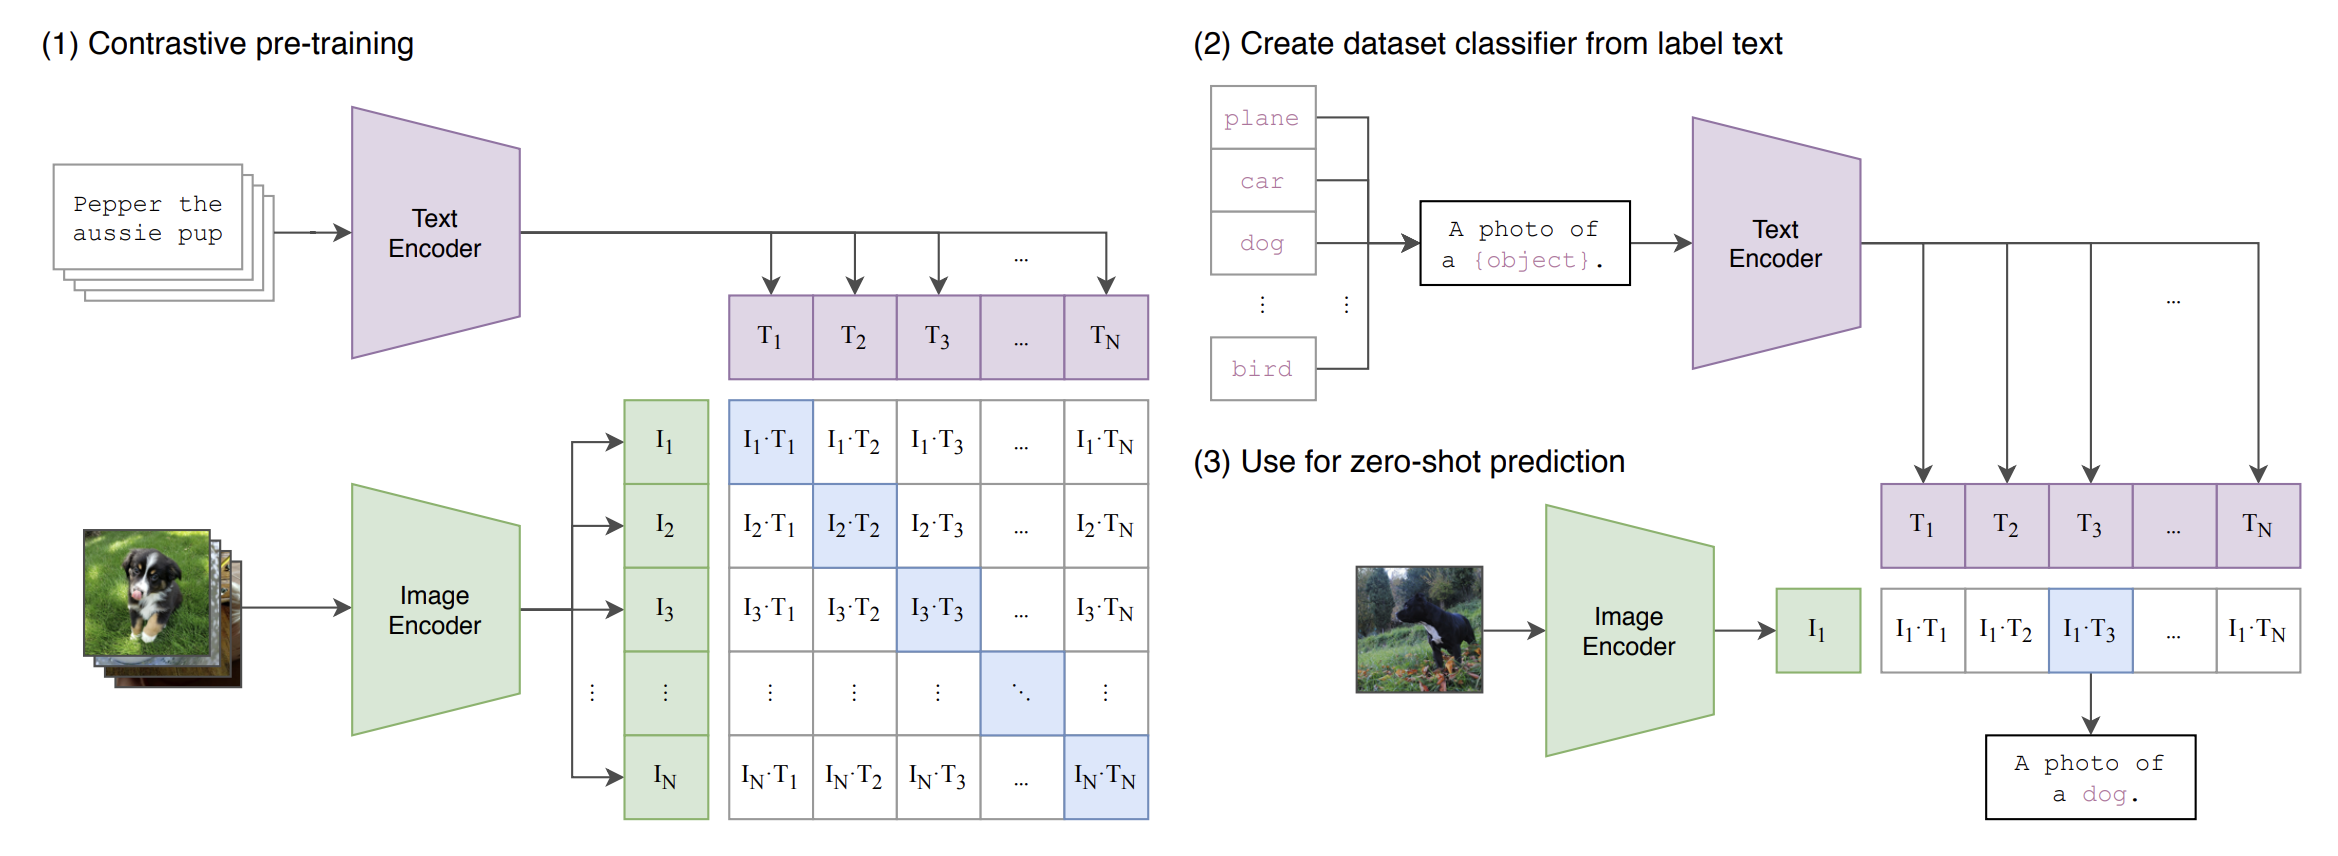


CLIP generalizes the embedding ide, instead of just words, both images and text become vectors in the SAME space, allowing cross-modal retrieval.

**Note:** This section benefits from GPU runtime. Go to Runtime → Change runtime type → GPU.

In [45]:
# CLIP setup (with CPU fallback)
import torch

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("Running on CPU, this will be slower. Consider switching to GPU runtime.")

# Set torch seed
torch.manual_seed(SEED)

import open_clip
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.to(device)
clip_model.eval()
CLIP_AVAILABLE = True
print(f"CLIP model loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in clip_model.parameters()):,}")

Using device: cuda


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP model loaded successfully!
Model parameters: 151,277,313


100%|██████████| 170M/170M [00:18<00:00, 9.05MB/s]


CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Selected 100 images (10 per class)


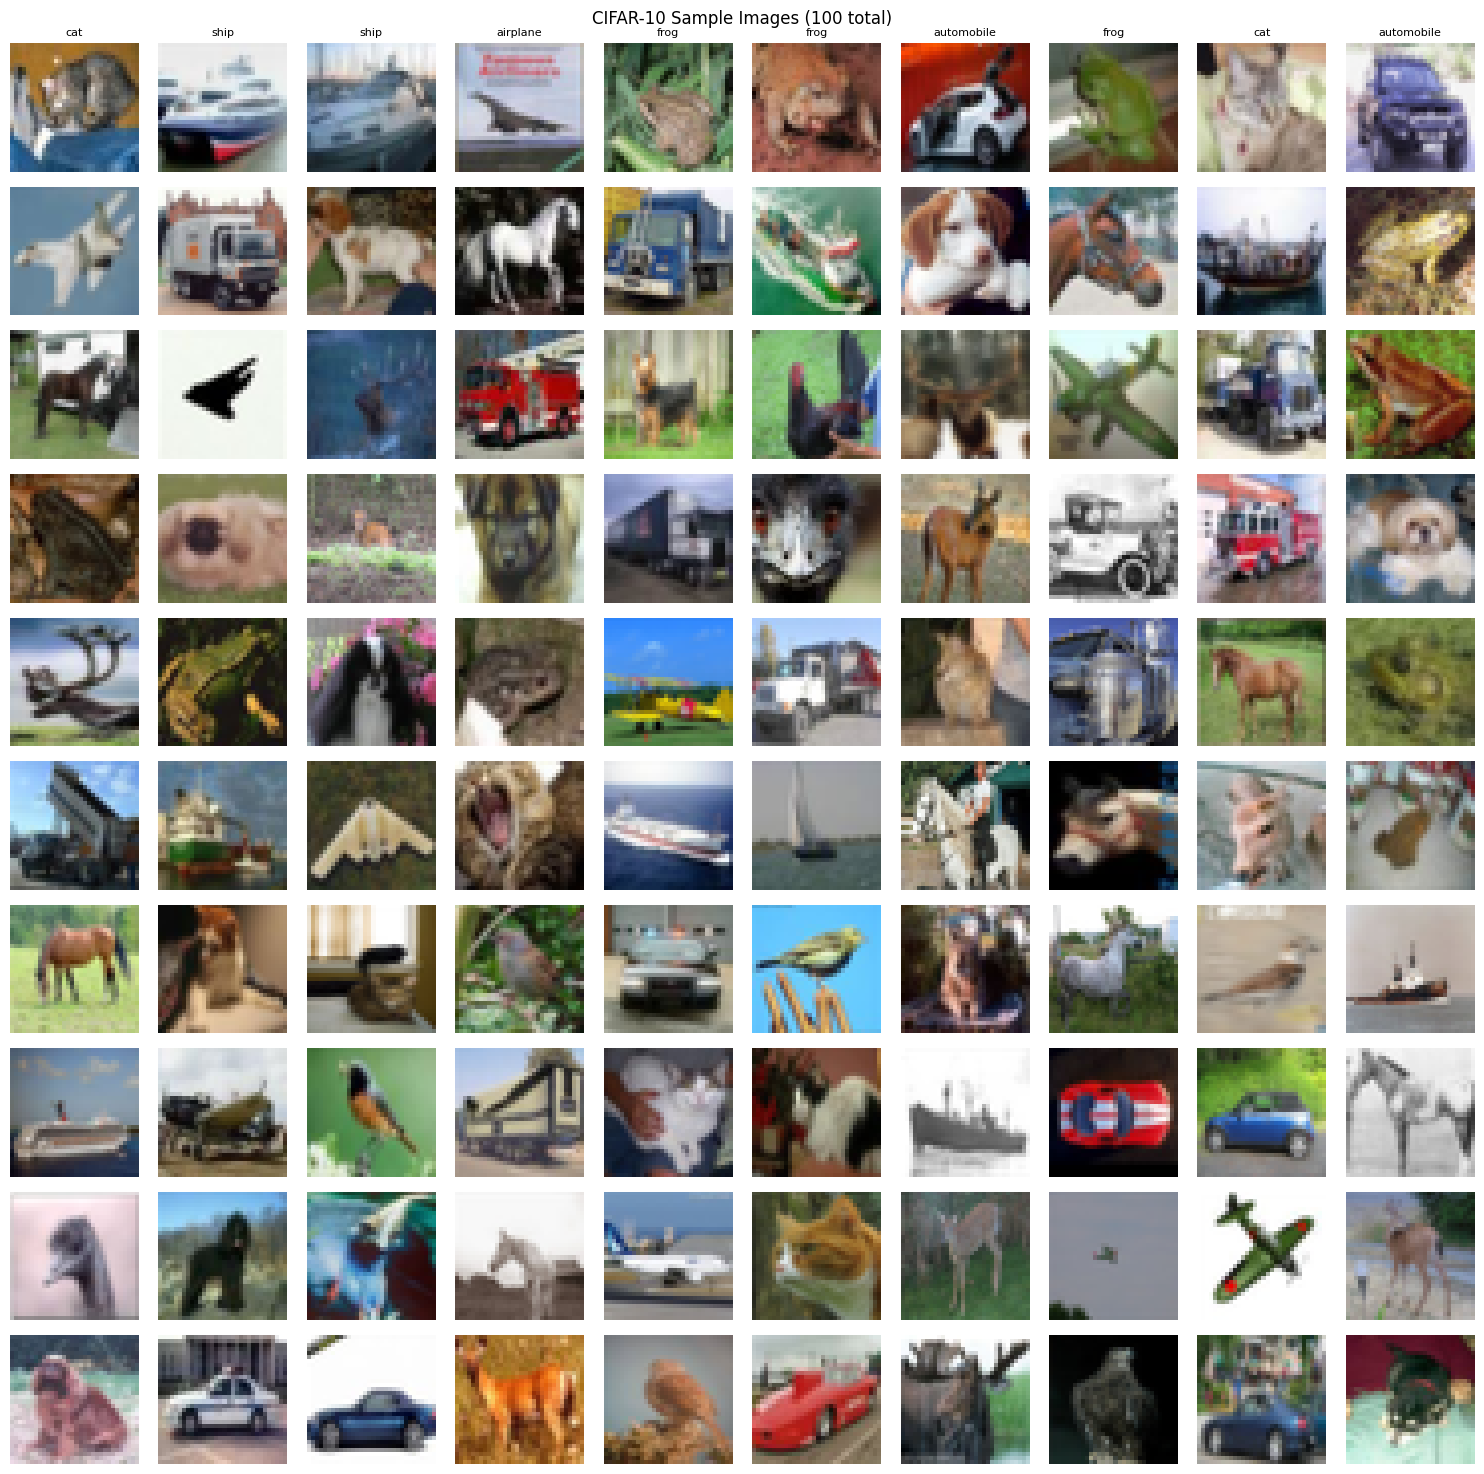

In [46]:
# Load CIFAR-10 images
from torchvision.datasets import CIFAR10
import torchvision.transforms as T
from PIL import Image

cifar10 = CIFAR10(root='./data', train=False, download=True)
class_names = cifar10.classes
print(f"CIFAR-10 classes: {class_names}")

# Select 10 images per class = 100 images total
# On CPU, reduce to 50 images for speed
images_per_class = 5 if device == "cpu" else 10
selected_images = []
selected_labels = []
class_counts = Counter()

for img, label in cifar10:
    if class_counts[label] < images_per_class:
        selected_images.append(img)
        selected_labels.append(label)
        class_counts[label] += 1
    if all(c >= images_per_class for c in class_counts.values()):
        break

print(f"Selected {len(selected_images)} images ({images_per_class} per class)")

# Display grid
n_cols = 10
n_rows = images_per_class
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 1.5 * n_rows))
for i, (img, label) in enumerate(zip(selected_images, selected_labels)):
    row, col = i // n_cols, i % n_cols
    if n_rows > 1:
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(class_names[label], fontsize=8)
    else:
        axes[col].imshow(img)
        axes[col].axis('off')
        axes[col].set_title(class_names[label], fontsize=8)
plt.suptitle(f'CIFAR-10 Sample Images ({len(selected_images)} total)')
plt.tight_layout()
plt.show()

In [47]:
# Encode images with CLIP
print("Encoding images...")
image_features = []
with torch.no_grad():
    for img in selected_images:
        img_tensor = clip_preprocess(img).unsqueeze(0).to(device)
        feat = clip_model.encode_image(img_tensor)
        feat = feat / feat.norm(dim=-1, keepdim=True)  # L2 normalize
        image_features.append(feat.cpu().numpy().flatten())

image_features = np.array(image_features)
print(f"Image features shape: {image_features.shape}")  # (N, 512)

Encoding images...
Image features shape: (100, 512)


Encoding text queries...
Text features shape: (4, 512)

Query: 'a photo of a cat'
Top 5 results:


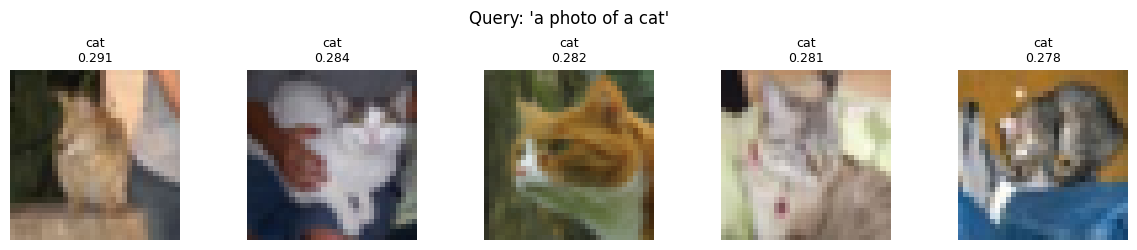


Query: 'a red car'
Top 5 results:


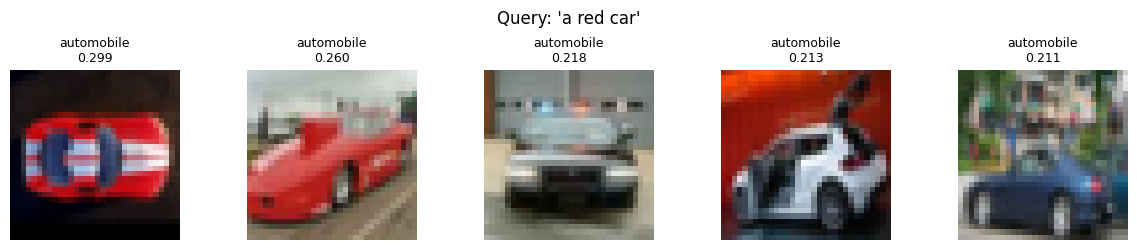


Query: 'an airplane in the sky'
Top 5 results:


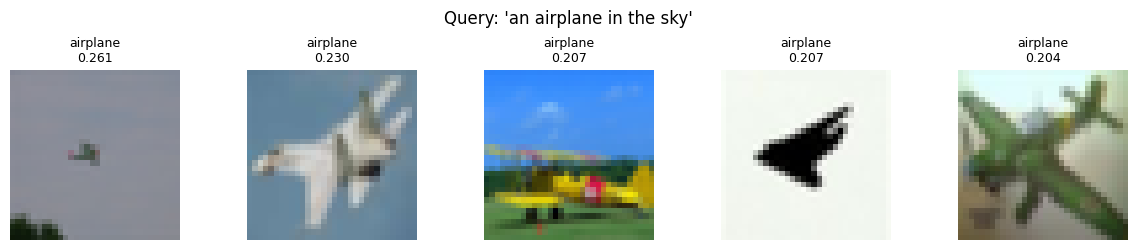


Query: 'a dog playing'
Top 5 results:


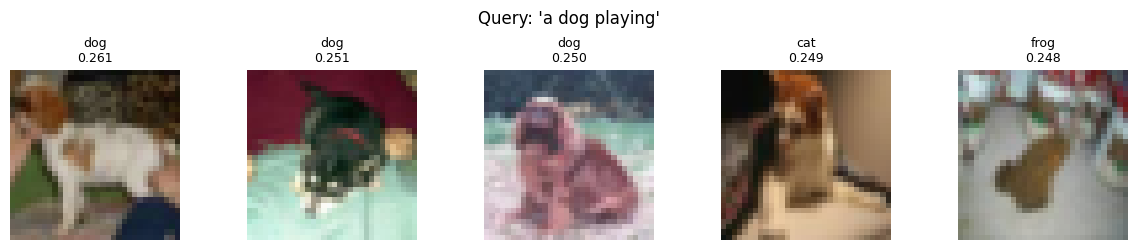

In [48]:
# Text-to-image retrieval
queries = [
    "a photo of a cat",
    "a red car",
    "an airplane in the sky",
    "a dog playing",
]

print("Encoding text queries...")
text_features = []
with torch.no_grad():
    for query in queries:
        text_tokens = tokenizer([query]).to(device)
        feat = clip_model.encode_text(text_tokens)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        text_features.append(feat.cpu().numpy().flatten())

text_features = np.array(text_features)
print(f"Text features shape: {text_features.shape}")

# Compute similarities
similarities = text_features @ image_features.T  # (n_queries, n_images)

# Display top-5 results per query
for qi, query in enumerate(queries):
    top5_idx = np.argsort(similarities[qi])[::-1][:5]
    print(f"\nQuery: '{query}'")
    print(f"Top 5 results:")

    fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
    for rank, idx in enumerate(top5_idx):
        axes[rank].imshow(selected_images[idx])
        axes[rank].set_title(f"{class_names[selected_labels[idx]]}\n{similarities[qi, idx]:.3f}",
                            fontsize=9)
        axes[rank].axis('off')
    plt.suptitle(f"Query: '{query}'", fontsize=12)
    plt.tight_layout()
    plt.show()

In [49]:
# Precision@5 analysis
# Map queries to expected classes
query_expected = {
    "a photo of a cat": "cat",
    "a red car": "automobile",
    "an airplane in the sky": "airplane",
    "a dog playing": "dog",
}

print("=== Precision@5 Analysis ===\n")
for qi, query in enumerate(queries):
    top5_idx = np.argsort(similarities[qi])[::-1][:5]
    expected = query_expected[query]
    correct = sum(1 for idx in top5_idx if class_names[selected_labels[idx]] == expected)
    print(f"  '{query}': {correct}/5 correct (P@5 = {correct/5:.1%})")
    retrieved_classes = [class_names[selected_labels[idx]] for idx in top5_idx]
    print(f"    Retrieved: {retrieved_classes}")

=== Precision@5 Analysis ===

  'a photo of a cat': 5/5 correct (P@5 = 100.0%)
    Retrieved: ['cat', 'cat', 'cat', 'cat', 'cat']
  'a red car': 5/5 correct (P@5 = 100.0%)
    Retrieved: ['automobile', 'automobile', 'automobile', 'automobile', 'automobile']
  'an airplane in the sky': 5/5 correct (P@5 = 100.0%)
    Retrieved: ['airplane', 'airplane', 'airplane', 'airplane', 'airplane']
  'a dog playing': 3/5 correct (P@5 = 60.0%)
    Retrieved: ['dog', 'dog', 'dog', 'cat', 'frog']


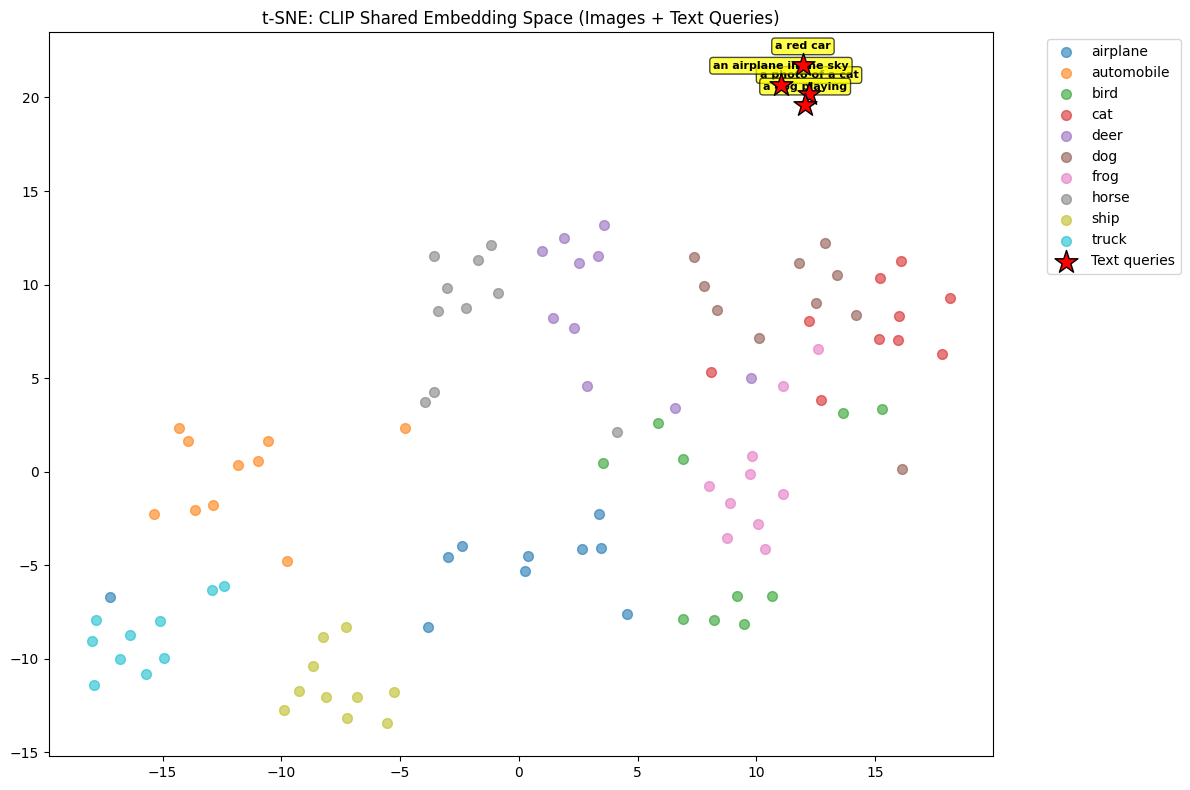

Text queries (red stars) should appear near their corresponding image clusters.


In [50]:
# Shared space visualization: t-SNE of images + text queries
# Combine image and text features
all_features = np.vstack([image_features, text_features])
all_labels = [class_names[l] for l in selected_labels] + [f"QUERY: {q}" for q in queries]
is_query = [False] * len(selected_images) + [True] * len(queries)

tsne_clip = TSNE(n_components=2, perplexity=15, random_state=SEED, n_iter=1000)
clip_2d = tsne_clip.fit_transform(all_features)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Image points (colored by class)
unique_classes = list(set(class_names[l] for l in selected_labels))
colors_map = plt.cm.tab10(np.linspace(0, 1, 10))
for ci, cls in enumerate(cifar10.classes):
    mask = [class_names[selected_labels[i]] == cls for i in range(len(selected_images))]
    pts = clip_2d[:len(selected_images)][mask]
    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], c=[colors_map[ci]], label=cls, s=50, alpha=0.6)

# Text query points (red stars)
query_pts = clip_2d[len(selected_images):]
ax.scatter(query_pts[:, 0], query_pts[:, 1], c='red', marker='*', s=300,
          zorder=10, label='Text queries', edgecolors='black', linewidths=1)
for i, query in enumerate(queries):
    ax.annotate(query, (query_pts[i, 0], query_pts[i, 1]),
                fontsize=8, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title('t-SNE: CLIP Shared Embedding Space (Images + Text Queries)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("Text queries (red stars) should appear near their corresponding image clusters.")

### Shortcomings of CLIP

In [56]:
# --- Shortcoming 1: Prompt engineering matters ---
print("=== Prompt Engineering Sensitivity ===\n")
prompt_variants = [
    "dog",
    "a dog",
    "a photo of a dog",
    "a cute dog",
    "a photograph of a domestic dog",
]

print("Different phrasings for the same concept ('dog'):\n")
for prompt in prompt_variants:
    with torch.no_grad():
        tokens = tokenizer([prompt]).to(device)
        feat = clip_model.encode_text(tokens)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        feat = feat.cpu().numpy().flatten()

    sims = feat @ image_features.T
    top5_idx = np.argsort(sims)[::-1][:5]
    top5_classes = [class_names[selected_labels[i]] for i in top5_idx]
    cat_count = sum(1 for c in top5_classes if c == 'dog')
    print(f"  '{prompt}': P@5 = {cat_count}/5, classes = {top5_classes}")

print("\nPhrasing significantly affects retrieval quality!")

=== Prompt Engineering Sensitivity ===

Different phrasings for the same concept ('dog'):

  'dog': P@5 = 4/5, classes = ['dog', 'dog', 'bird', 'dog', 'dog']
  'a dog': P@5 = 3/5, classes = ['dog', 'dog', 'dog', 'bird', 'cat']
  'a photo of a dog': P@5 = 4/5, classes = ['dog', 'dog', 'dog', 'cat', 'dog']
  'a cute dog': P@5 = 4/5, classes = ['dog', 'dog', 'dog', 'cat', 'dog']
  'a photograph of a domestic dog': P@5 = 3/5, classes = ['dog', 'frog', 'cat', 'dog', 'dog']

Phrasing significantly affects retrieval quality!


In [57]:
# --- Shortcoming 2: Compositional understanding is weak ---
print("=== Weak Compositional Understanding ===\n")
compositional_queries = [
    ("a red car", "a blue car"),
    ("a cat on a truck", "a truck on a cat"),
    ("a bird flying over water", "water flying over a bird"),
]

for q1, q2 in compositional_queries:
    with torch.no_grad():
        t1 = tokenizer([q1]).to(device)
        t2 = tokenizer([q2]).to(device)
        f1 = clip_model.encode_text(t1)
        f2 = clip_model.encode_text(t2)
        f1 = f1 / f1.norm(dim=-1, keepdim=True)
        f2 = f2 / f2.norm(dim=-1, keepdim=True)
        sim = (f1 @ f2.T).item()
    print(f"  sim('{q1}', '{q2}') = {sim:.4f}")

print("\n CLIP often gives high similarity to semantically different compositional phrases.")
print("  It tends to match individual concepts rather than their relationships.")

=== Weak Compositional Understanding ===

  sim('a red car', 'a blue car') = 0.6287
  sim('a cat on a truck', 'a truck on a cat') = 0.9542
  sim('a bird flying over water', 'water flying over a bird') = 0.9201

→ CLIP often gives high similarity to semantically different compositional phrases.
  It tends to match individual concepts rather than their relationships.


In [58]:
# --- Shortcoming 3: Compute cost comparison ---
print("=== Compute Cost Comparison ===\n")

# GloVe cosine similarity timing
t0 = time.time()
for _ in range(1000):
    cosine_sim(glove['cat'], glove['dog'])
glove_time = time.time() - t0

# CLIP encoding + similarity timing
t0 = time.time()
with torch.no_grad():
    for _ in range(100):
        tokens = tokenizer(["a cat"]).to(device)
        feat = clip_model.encode_text(tokens)
clip_time = (time.time() - t0) * 10  # scale to 1000

print(f"  1000 GloVe cosine similarities: {glove_time:.3f}s")
print(f"  1000 CLIP text encodings (estimated): {clip_time:.3f}s")
print(f"  CLIP is ~{clip_time/glove_time:.0f}x slower")
print("\n→ The rich representations of CLIP come at significant compute cost.")

=== Compute Cost Comparison ===

  1000 GloVe cosine similarities: 0.010s
  1000 CLIP text encodings (estimated): 11.637s
  CLIP is ~1197x slower

→ The rich representations of CLIP come at significant compute cost.


### Exercise 7: CLIP Exploration

**Tasks:**
1. **(a)** Write 10 creative text queries beyond simple class names (e.g., "a vehicle driving on a road", "an animal with whiskers"). Analyze which retrieve correctly.
2. **(b)** Implement image-to-image retrieval: pick an image, find the 5 most similar images using CLIP features vs raw pixel cosine similarity. Compare results.
3. **(c)** (Challenge) Download STL-10 (96×96 images) or use custom images. Compare retrieval quality to CIFAR-10.

In [54]:
# Exercise 7: Your code here (only runs if CLIP is available)

# TODO (a): 10 creative queries
creative_queries = [
    # "a vehicle driving on a road",
    # "an animal with whiskers",
    # TODO: add 10 creative queries
]
# TODO: Encode queries and compute similarities
# TODO: Display top-5 results for each

# TODO (b): Image-to-image retrieval
# Pick a query image, compute cosine similarity to all others using CLIP features
# Compare with raw pixel cosine similarity

# TODO (c): STL-10 challenge (optional)
pass

In [55]:
# @title Solution — Exercise 7 (click to expand)

# # --- Part (a): Creative queries ---
# creative_queries = [
#     "a vehicle driving on a road",
#     "an animal with whiskers",
#     "something that flies in the sky",
#     "a four-legged animal",
#     "a piece of technology",
#     "something you find in the ocean",
#     "a vehicle with wheels",
#     "a wild animal",
#     "something that floats on water",
#     "a small furry pet",
# ]

# print("=== Creative Query Retrieval ===\n")
# for query in creative_queries:
#     with torch.no_grad():
#         tokens = tokenizer([query]).to(device)
#         feat = clip_model.encode_text(tokens)
#         feat = feat / feat.norm(dim=-1, keepdim=True)
#         feat = feat.cpu().numpy().flatten()
#     sims = feat @ image_features.T
#     top5_idx = np.argsort(sims)[::-1][:5]
#     top5_classes = [class_names[selected_labels[i]] for i in top5_idx]
#     print(f"  '{query}': {top5_classes}")

# # --- Part (b): Image-to-image retrieval ---
# print("\n=== Image-to-Image Retrieval (CLIP vs Pixels) ===\n")
# query_idx = 0  # First image as query
# query_label = class_names[selected_labels[query_idx]]
# print(f"Query image: index {query_idx} (class: {query_label})")

# # CLIP-based similarity
# clip_sims = image_features[query_idx] @ image_features.T
# clip_sims[query_idx] = -1  # exclude self
# clip_top5 = np.argsort(clip_sims)[::-1][:5]

# # Pixel-based similarity
# query_pixels = np.array(selected_images[query_idx]).flatten().astype(float)
# pixel_sims = []
# for i, img in enumerate(selected_images):
#     pix = np.array(img).flatten().astype(float)
#     pixel_sims.append(cosine_sim(query_pixels, pix))
# pixel_sims = np.array(pixel_sims)
# pixel_sims[query_idx] = -1
# pixel_top5 = np.argsort(pixel_sims)[::-1][:5]

# fig, axes = plt.subplots(2, 6, figsize=(15, 5))
# axes[0, 0].imshow(selected_images[query_idx])
# axes[0, 0].set_title(f"Query: {query_label}", fontsize=9)
# axes[0, 0].axis('off')
# axes[1, 0].imshow(selected_images[query_idx])
# axes[1, 0].set_title(f"Query: {query_label}", fontsize=9)
# axes[1, 0].axis('off')

# for rank, idx in enumerate(clip_top5):
#     axes[0, rank+1].imshow(selected_images[idx])
#     axes[0, rank+1].set_title(f"CLIP: {class_names[selected_labels[idx]]}\n{clip_sims[idx]:.3f}", fontsize=8)
#     axes[0, rank+1].axis('off')

# for rank, idx in enumerate(pixel_top5):
#     axes[1, rank+1].imshow(selected_images[idx])
#     axes[1, rank+1].set_title(f"Pixel: {class_names[selected_labels[idx]]}\n{pixel_sims[idx]:.3f}", fontsize=8)
#     axes[1, rank+1].axis('off')

# plt.suptitle("Image-to-Image Retrieval: CLIP features vs Raw Pixels")
# plt.tight_layout()
# plt.show()

# print("→ CLIP retrieves semantically similar images; pixel similarity matches color/texture.")
# print("\n✓ Exercise 7 complete.")


---
## Summary

### What we learned:

| Method | Key Idea | Strengths | Weaknesses |
|---|---|---|---|
| **GloVe** | Co-occurrence matrix factorization | Fast, good quality pre-trained | No OOV, static, frequency bias |
| **Word2Vec** | Prediction task (SG/CBOW) | Trainable on custom data | No OOV, static, corpus-dependent |
| **FastText** | Subword n-grams | OOV handling, morphology | Larger, slower, n-gram collisions |
| **LSA** | TF-IDF + SVD | Documents as vectors, topic discovery | Linear, no word order, k-sensitive |
| **CLIP** | Contrastive image-text learning | Cross-modal retrieval | Compute-heavy, prompt-sensitive |

### Key takeaways:
1. **All embeddings are approximations** — they capture distributional patterns, not true meaning
2. **Static embeddings have fundamental limits** — one vector per word cannot capture polysemy
3. **Geometry is useful but imperfect** — the parallelogram rule is a rough heuristic, not a law
4. **Biases in training data become biases in embeddings** — always be aware of this
5. **The embedding idea generalizes** — from words to documents (LSA) to images (CLIP)

### What comes next:
- **Contextual embeddings** (ELMo, BERT, GPT) solve the polysemy problem with dynamic, context-dependent vectors
- **Sentence/document transformers** replace LSA with learned representations
- **Foundation models** (GPT-4, Claude) build on these ideas at massive scale